# ML1: Flakiness Classifier


In [4]:
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit

DB_PATH    = 'analytics.db'
MODEL_DIR  = 'ml_models'
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [5]:
conn = sqlite3.connect(DB_PATH)

df_results = pd.read_sql_query(
    """
    SELECT
        tr.result_id,
        tr.run_id,
        tr.test_name,
        tr.status,
        tr.duration_s,
        tr.failure_msg,
        tr.failure_kw,
        tr.tags,
        r.build_no,
        r.timestamp,
        r.pass_rate_pct,
        r.suite_name AS program
    FROM test_results tr
    JOIN runs r ON tr.run_id = r.run_id
    ORDER BY tr.test_name, r.build_no
    """,
    conn
)

conn.close()

df_results['status_binary'] = (df_results['status'] == 'FAIL').astype(int)

import json
def parse_tag(tags_json, position):
    """Extract tag at given position from JSON array string."""
    try:
        tags = json.loads(tags_json)
        return tags[position] if len(tags) > position else None
    except:
        return None

df_results['feature_tag'] = df_results['tags'].apply(lambda x: parse_tag(x, 1))
df_results['priority_tag'] = df_results['tags'].apply(lambda x: parse_tag(x, 2))

print(f"Loaded {len(df_results):,} test-result rows")
print(f"Unique tests: {df_results['test_name'].nunique()}")
print(f"Build range: {df_results['build_no'].min()} – {df_results['build_no'].max()}")
print(f"Overall fail rate: {df_results['status_binary'].mean():.1%}")
df_results.head()

Loaded 2,000 test-result rows
Unique tests: 20
Build range: 1 – 100
Overall fail rate: 24.6%


,result_id,run_id,test_name,status,duration_s,failure_msg,failure_kw,tags,build_no,timestamp,pass_rate_pct,program,status_binary,feature_tag,priority_tag
0,alpha_build_001_TC_Dashboard_ExportChart,alpha_build_001,TC_Dashboard_ExportChart,PASS,4.518,None,None,"[""alpha_regression"", ""feature_dashboard"", ""pri...",1,2024-10-01T00:00:00,75.0,alpha,0,feature_dashboard,priority_medium
1,alpha_build_002_TC_Dashboard_ExportChart,alpha_build_002,TC_Dashboard_ExportChart,PASS,4.255,None,None,"[""alpha_regression"", ""feature_dashboard"", ""pri...",2,2024-10-02T00:00:00,75.0,alpha,0,feature_dashboard,priority_medium
2,alpha_build_003_TC_Dashboard_ExportChart,alpha_build_003,TC_Dashboard_ExportChart,PASS,3.142,None,None,"[""alpha_regression"", ""feature_dashboard"", ""pri...",3,2024-10-03T00:00:00,80.0,alpha,0,feature_dashboard,priority_medium
3,alpha_build_004_TC_Dashboard_ExportChart,alpha_build_004,TC_Dashboard_ExportChart,PASS,3.114,None,None,"[""alpha_regression"", ""feature_dashboard"", ""pri...",4,2024-10-04T00:00:00,75.0,alpha,0,feature_dashboard,priority_medium
4,alpha_build_005_TC_Dashboard_ExportChart,alpha_build_005,TC_Dashboard_ExportChart,PASS,3.262,None,None,"[""alpha_regression"", ""feature_dashboard"", ""pri...",5,2024-10-05T00:00:00,70.0,alpha,0,feature_dashboard,priority_medium


In [6]:
WINDOW_SIZE = 20
MIN_HISTORY  = 10

def build_features_for_test(df_test, window_size=WINDOW_SIZE, min_history=MIN_HISTORY):
    df = df_test.reset_index(drop=True)
    n = len(df)

    rows = []

    for i in range(min_history, n - 1):
        # Past window: runs [i-window_size+1, i]
        start = max(0, i - window_size + 1)
        past = df.iloc[start : i+1].copy()

        target = df.iloc[i+1]['status_binary']

        fail_rate_last_5  = past['status_binary'].tail(5).mean()
        fail_rate_last_10 = past['status_binary'].tail(10).mean()
        fail_rate_last_20 = past['status_binary'].tail(20).mean()

        status_seq = past['status_binary'].values
        flips = np.sum(np.abs(np.diff(status_seq)))
        flip_count_last_w = flips
        flip_rate_last_w  = flips / max(len(status_seq)-1, 1)

        consecutive_fails = 0
        consecutive_passes = 0
        for s in reversed(status_seq):
            if s == 1:
                consecutive_fails += 1
            else:
                break
        for s in reversed(status_seq):
            if s == 0:
                consecutive_passes += 1
            else:
                break

        pass_mask = past['status'] == 'PASS'
        fail_mask = past['status'] == 'FAIL'
        avg_dur_pass_5 = past[pass_mask]['duration_s'].tail(5).mean() if pass_mask.any() else np.nan
        avg_dur_fail_5 = past[fail_mask]['duration_s'].tail(5).mean() if fail_mask.any() else np.nan
        duration_last   = past.iloc[-1]['duration_s']

        timestamps = pd.to_datetime(past['timestamp'])
        time_since_last = (timestamps.iloc[-1] - timestamps.iloc[-2]).total_seconds() / 86400.0 if len(timestamps) >= 2 else np.nan

        run_pass_rate = past.iloc[-1]['pass_rate_pct']

        feature_tag = past.iloc[-1]['feature_tag']
        priority_tag = past.iloc[-1]['priority_tag']
        test_name   = past.iloc[-1]['test_name']
        build_no    = df.iloc[i+1]['build_no']
        timestamp_target = df.iloc[i+1]['timestamp']

        rows.append({
            'test_name': test_name,
            'build_no_target': build_no,
            'timestamp_target': timestamp_target,
            'fail_rate_last_5': fail_rate_last_5,
            'fail_rate_last_10': fail_rate_last_10,
            'fail_rate_last_20': fail_rate_last_20,
            'flip_count_last_w': flip_count_last_w,
            'flip_rate_last_w': flip_rate_last_w,
            'consecutive_failures': consecutive_fails,
            'consecutive_passes': consecutive_passes,
            'avg_dur_pass_5': avg_dur_pass_5,
            'avg_dur_fail_5': avg_dur_fail_5,
            'duration_last': duration_last,
            'time_since_last': time_since_last,
            'run_pass_rate': run_pass_rate,
            'feature_tag': feature_tag,
            'priority_tag': priority_tag,
            'target': target,
        })

    return pd.DataFrame(rows)


all_features = []

for test_name, group in df_results.groupby('test_name'):
    feat_df = build_features_for_test(group)
    all_features.append(feat_df)

df_features = pd.concat(all_features, ignore_index=True)

df_features = df_features.fillna({
    'avg_dur_pass_5': df_features['avg_dur_pass_5'].median(),
    'avg_dur_fail_5': df_features['avg_dur_fail_5'].median(),
    'time_since_last': 1.0,
})

print(f"Training examples created: {len(df_features):,}")
print(f"Target distribution: FAIL={df_features['target'].sum():,} ({df_features['target'].mean():.1%}), "
      f"PASS={(1-df_features['target']).sum():,} ({(1-df_features['target'].mean()):.1%})")
df_features.head()

Training examples created: 1,780
Target distribution: FAIL=441 (24.8%), PASS=1,339 (75.2%)


,test_name,build_no_target,timestamp_target,fail_rate_last_5,fail_rate_last_10,fail_rate_last_20,flip_count_last_w,flip_rate_last_w,consecutive_failures,consecutive_passes,avg_dur_pass_5,avg_dur_fail_5,duration_last,time_since_last,run_pass_rate,feature_tag,priority_tag,target
0,TC_Dashboard_ExportChart,12,2024-10-12T00:00:00,0.0,0.0,0.0,0,0.0,0,11,3.7542,14.8978,3.450,1.0,80.0,feature_dashboard,priority_medium,0
1,TC_Dashboard_ExportChart,13,2024-10-13T00:00:00,0.0,0.0,0.0,0,0.0,0,12,3.7250,14.8978,3.969,1.0,70.0,feature_dashboard,priority_medium,0
2,TC_Dashboard_ExportChart,14,2024-10-14T00:00:00,0.0,0.0,0.0,0,0.0,0,13,3.7944,14.8978,3.677,1.0,80.0,feature_dashboard,priority_medium,0
3,TC_Dashboard_ExportChart,15,2024-10-15T00:00:00,0.0,0.0,0.0,0,0.0,0,14,4.1520,14.8978,4.999,1.0,75.0,feature_dashboard,priority_medium,0
4,TC_Dashboard_ExportChart,16,2024-10-16T00:00:00,0.0,0.0,0.0,0,0.0,0,15,4.0786,14.8978,4.298,1.0,80.0,feature_dashboard,priority_medium,0


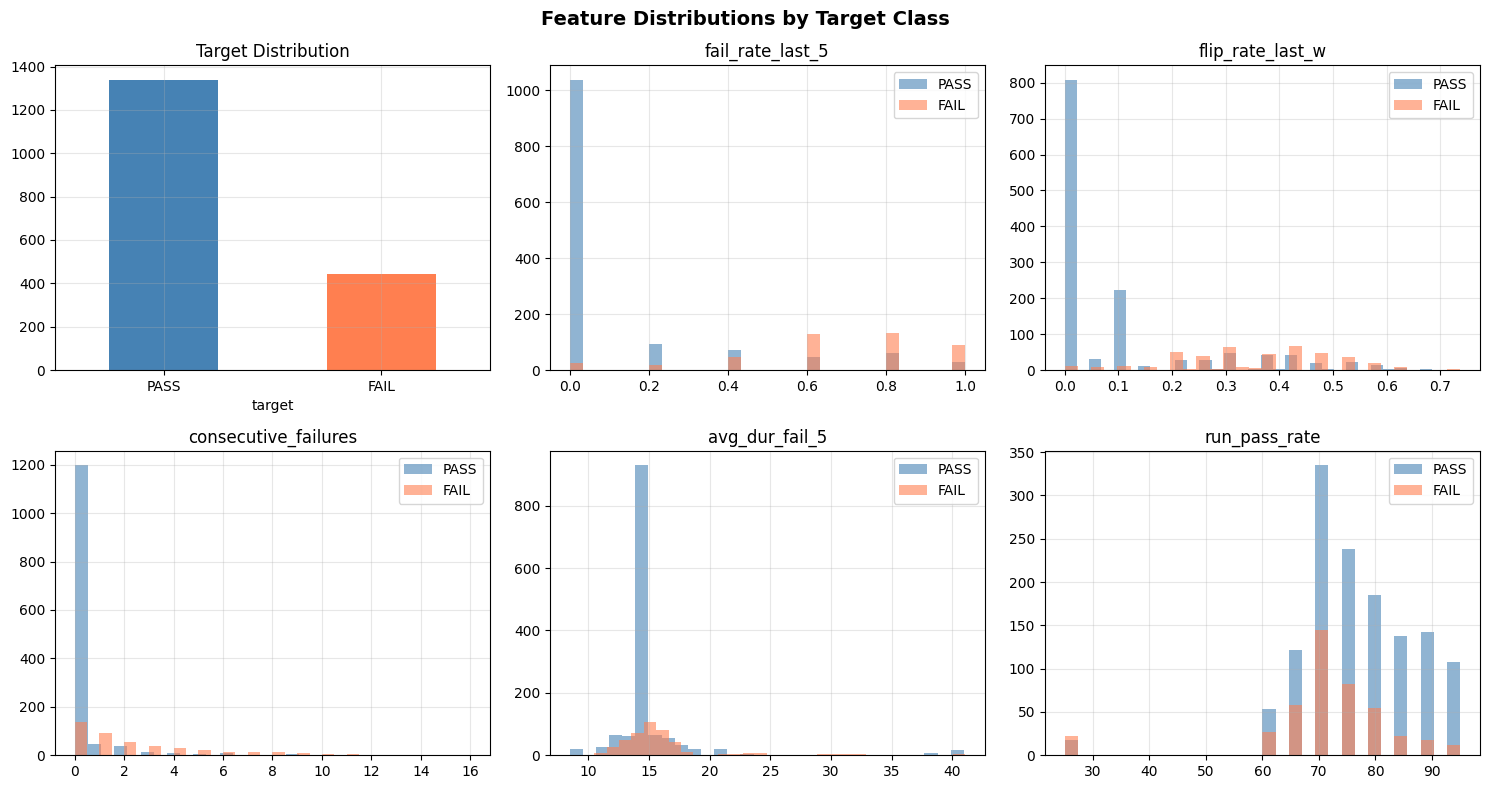

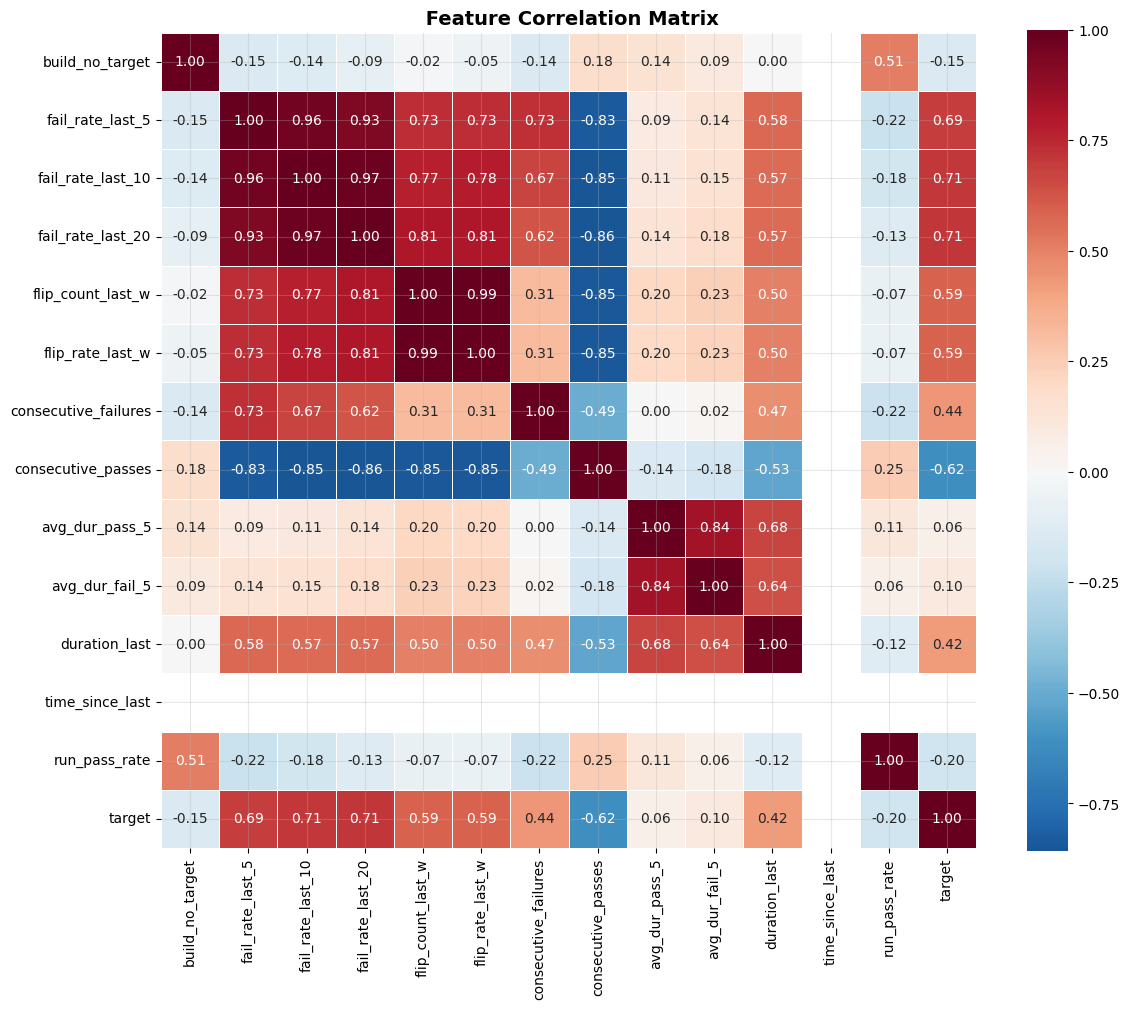

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

df_features['target'].value_counts().plot.bar(ax=axes[0,0], color=['steelblue','coral'])
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xticklabels(['PASS', 'FAIL'], rotation=0)

features_to_plot = ['fail_rate_last_5', 'flip_rate_last_w', 'consecutive_failures',
                     'avg_dur_fail_5', 'run_pass_rate']

for ax, feat in zip(axes.flatten()[1:], features_to_plot):
    for label, color in [(0, 'steelblue'), (1, 'coral')]:
        subset = df_features[df_features['target'] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=f"{'PASS' if label==0 else 'FAIL'}", color=color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

numeric_cols = df_features.select_dtypes(include=[np.number]).columns
corr = df_features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title(' Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
builds_sorted = sorted(df_features['build_no_target'].unique())
train_cutoff = np.percentile(builds_sorted, 75)
val_cutoff   = np.percentile(builds_sorted, 90)

df_train = df_features[df_features['build_no_target'] <= train_cutoff]
df_val   = df_features[(df_features['build_no_target'] > train_cutoff) &
                         (df_features['build_no_target'] <= val_cutoff)]
df_test  = df_features[df_features['build_no_target'] > val_cutoff]

print(f"Train: {len(df_train):,} examples (builds ≤ {train_cutoff:.0f}) 75%")
print(f"Val:   {len(df_val):,} examples (builds {train_cutoff:.0f}–{val_cutoff:.0f}) 15%")
print(f"Test:  {len(df_test):,} examples (builds > {val_cutoff:.0f}) 10%")
print(f"\nTrain fail rate: {df_train['target'].mean():.1%}")
print(f"Val fail rate:   {df_val['target'].mean():.1%}")
print(f"Test fail rate:  {df_test['target'].mean():.1%}")

Train: 1,340 examples (builds ≤ 78) 75%
Val:   260 examples (builds 78–91) 15%
Test:  180 examples (builds > 91) 10%

Train fail rate: 29.0%
Val fail rate:   12.3%
Test fail rate:  11.1%


In [9]:
exclude_cols = ['test_name', 'build_no_target', 'timestamp_target', 'target']
feature_cols = [c for c in df_features.columns if c not in exclude_cols]

df_train_enc = pd.get_dummies(df_train[feature_cols], drop_first=True)
df_val_enc   = pd.get_dummies(df_val[feature_cols], drop_first=True)
df_test_enc  = pd.get_dummies(df_test[feature_cols], drop_first=True)

common_cols = df_train_enc.columns.intersection(df_val_enc.columns).intersection(df_test_enc.columns)
df_train_enc = df_train_enc[common_cols]
df_val_enc   = df_val_enc[common_cols]
df_test_enc  = df_test_enc[common_cols]

X_train, y_train = df_train_enc.values, df_train['target'].values
X_val,   y_val   = df_val_enc.values,   df_val['target'].values
X_test,  y_test  = df_test_enc.values,  df_test['target'].values

feature_names = list(common_cols)
print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Features: {feature_names}")

Feature matrix shape: (1340, 15)
Number of features: 15
Features: ['fail_rate_last_5', 'fail_rate_last_10', 'fail_rate_last_20', 'flip_count_last_w', 'flip_rate_last_w', 'consecutive_failures', 'consecutive_passes', 'avg_dur_pass_5', 'avg_dur_fail_5', 'duration_last', 'time_since_last', 'run_pass_rate', 'feature_tag_feature_login', 'feature_tag_feature_usermgmt', 'priority_tag_priority_medium']


In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

THRESHOLD = 0.75

y_val_proba = rf.predict_proba(X_val)[:, 1]
y_val_pred  = (y_val_proba >= THRESHOLD).astype(int)

print("Validation Set Performance")
print(classification_report(y_val, y_val_pred, target_names=['PASS', 'FAIL']))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

Validation Set Performance
              precision    recall  f1-score   support

        PASS       0.95      0.95      0.95       228
        FAIL       0.66      0.66      0.66        32

    accuracy                           0.92       260
   macro avg       0.80      0.80      0.80       260
weighted avg       0.92      0.92      0.92       260

ROC-AUC: 0.9430


Let's break down the validation set performance metrics:

*   **Precision (PASS)**: `0.95` - When the model predicts a test will pass, it is correct 95% of the time.
*   **Recall (PASS)**: `0.95` - The model correctly identifies 95% of all actual passing tests.
*   **F1-score (PASS)**: `0.95` - This indicates a strong balance between precision and recall for predicting passing tests.

*   **Precision (FAIL)**: `0.66` - When the model predicts a test will fail, it is correct 66% of the time.
*   **Recall (FAIL)**: `0.66` - The model correctly identifies 66% of all actual failing tests.
*   **F1-score (FAIL)**: `0.66` - This suggests a moderate balance between precision and recall for predicting failing tests. There's room for improvement here.

*   **Accuracy**: `0.92` - Overall, the model correctly predicts the status (pass or fail) for 92% of the tests in the validation set.
*   **ROC-AUC**: `0.9430` - This is a high score, indicating that the model has an excellent ability to distinguish between passing and failing tests. An AUC of 1.0 would be a perfect classifier, while 0.5 is equivalent to random guessing.

Test Set Performance
              precision    recall  f1-score   support

        PASS       0.95      0.95      0.95       160
        FAIL       0.60      0.60      0.60        20

    accuracy                           0.91       180
   macro avg       0.77      0.77      0.77       180
weighted avg       0.91      0.91      0.91       180

ROC-AUC: 0.8912


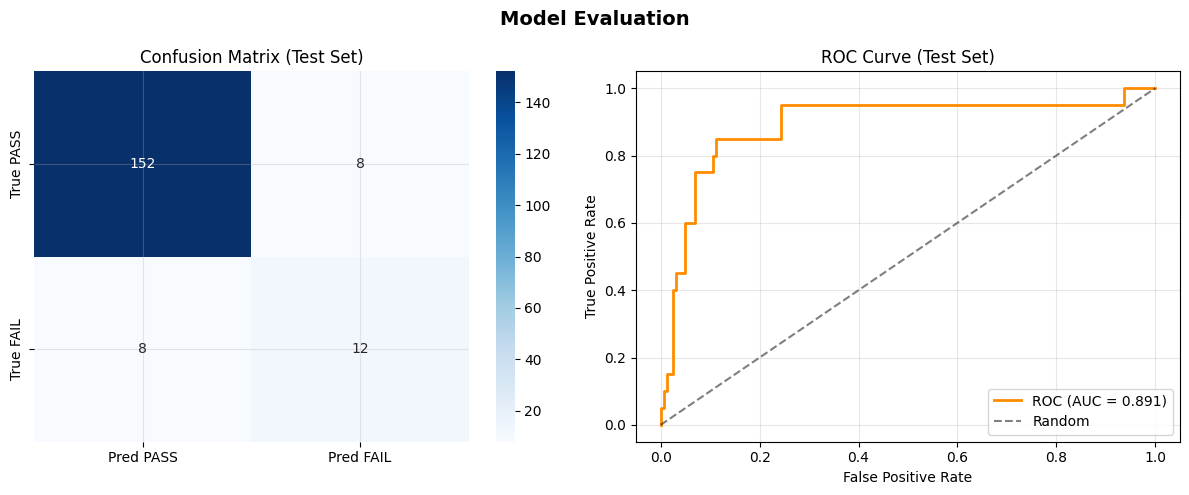

In [11]:
THRESHOLD = 0.7

y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= THRESHOLD).astype(int)

print("Test Set Performance")
print(classification_report(y_test, y_test_pred, target_names=['PASS', 'FAIL']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred PASS', 'Pred FAIL'],
            yticklabels=['True PASS', 'True FAIL'])
axes[0].set_title(f'Confusion Matrix (Test Set)')

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

axes[1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})', lw=2, color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)')
axes[1].legend()

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

On the unseen test set, the model's performance is consistent:

*   **Precision (FAIL)**: `0.60` - When the model predicts a failure on new data, it is correct 60% of the time.
*   **Recall (FAIL)**: `0.60` - The model correctly identifies 60% of actual failures in the test set.
*   **F1-score (FAIL)**: `0.60` - The F1-score of `0.60` for the 'FAIL' class suggests a reasonable balance in detecting failures on new, unseen data.
*   **ROC-AUC**: `0.8912` - The ROC-AUC remains high, confirming the model's robust ability to differentiate between passing and failing tests even on new data.

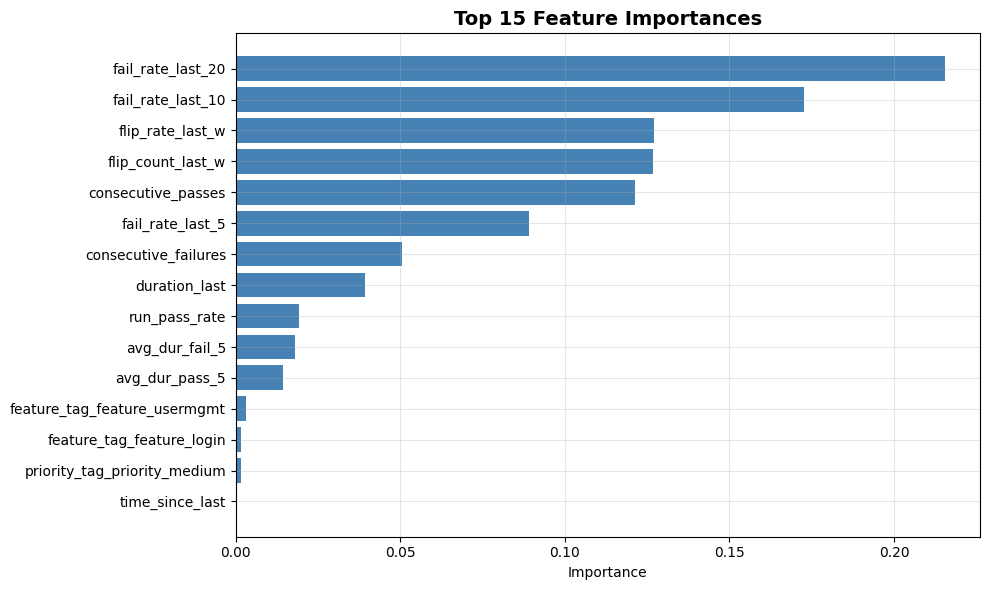

Top 10 features:
  fail_rate_last_20               0.2154
  fail_rate_last_10               0.1727
  flip_rate_last_w                0.1270
  flip_count_last_w               0.1267
  consecutive_passes              0.1214
  fail_rate_last_5                0.0891
  consecutive_failures            0.0506
  duration_last                   0.0393
  run_pass_rate                   0.0192
  avg_dur_fail_5                  0.0180


In [12]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices][::-1], color='steelblue')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices[::-1]])
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i in indices[:10]:
    print(f"  {feature_names[i]:30s}  {importances[i]:.4f}")

The feature importance plot reveals which features contribute most to the Random Forest model's predictions of test flakiness:

*   **Recent Failure Rates (e.g., `fail_rate_last_20`, `fail_rate_last_10`, `fail_rate_last_5`)** are consistently the most important features. This strongly suggests that a test's recent history of failures is the most indicative predictor of its future flakiness. The longer-term failure rates (`fail_rate_last_20`) appear slightly more influential than very short-term ones (`fail_rate_last_5`).
*   **Instability Metrics (`flip_rate_last_w`, `flip_count_last_w`)** also play a significant role. These features capture how often a test's status changes (flips between PASS/FAIL), indicating inherent instability which is a strong signal for flakiness.
*   **`consecutive_passes` and `consecutive_failures`** are important, reflecting momentum. Long streaks of passes or failures can provide valuable context for prediction.
*   **`duration_last`** also shows some importance, suggesting that the duration of the most recent run might contain subtle cues about an impending failure.

Overall, the model heavily relies on historical behavior patterns, with recent failure history and instability being paramount. The newly added `time_since_last_failure` could potentially also contribute to this predictive power, as it measures the recency of the last known failure event.

In [13]:
joblib.dump(rf, os.path.join(MODEL_DIR, 'flakiness_classifier.pkl'))
joblib.dump(feature_names, os.path.join(MODEL_DIR, 'flakiness_features.pkl'))

print(f"✓ Model saved to {MODEL_DIR}/flakiness_classifier.pkl")
print(f"✓ Feature names saved to {MODEL_DIR}/flakiness_features.pkl")

✓ Model saved to ml_models/flakiness_classifier.pkl
✓ Feature names saved to ml_models/flakiness_features.pkl


# ML2: Test Duration Drift Detection

In [14]:
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

DB_PATH    = 'analytics.db'
MODEL_DIR  = 'ml_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# DRIFT_WINDOW (15): Number of past PASS runs to establish a 'normal' baseline for duration.
# This is chosen to be long enough to get a stable mean but short enough to be reactive.
DRIFT_WINDOW = 15          # Number of past PASS runs for baseline

# DRIFT_SIGMA (3.0): Z-score threshold to flag a single run as unusually slow.
# A value of 3.0 represents 3 standard deviations, a common threshold for 'out-of-control' in SPC.
DRIFT_SIGMA  = 3.0         # How many std devs above mean to flag

# MIN_CONSECUTIVE (3): Number of consecutive flagged runs required to 'confirm' drift.
# This is to reduce false positives from transient spikes. Tuned to minimize noisy alerts.
MIN_CONSECUTIVE = 3        # How many consecutive alerts before "drift confirmed"

In [15]:
conn = sqlite3.connect(DB_PATH)

df_tests = pd.read_sql_query(
    """
    SELECT
        tr.result_id,
        tr.run_id,
        tr.test_name,
        tr.status,
        tr.duration_s,
        r.build_no,
        r.timestamp,
        r.suite_name AS program
    FROM test_results tr
    JOIN runs r ON tr.run_id = r.run_id
    WHERE r.build_no IS NOT NULL
    ORDER BY tr.test_name, r.build_no
    """,
    conn
)
conn.close()

df_tests['build_num'] = df_tests['run_id'].str.extract(r'(\d+)$').astype(int)

print(f"Loaded {len(df_tests):,} test-result rows")
print(f"Unique tests: {df_tests['test_name'].nunique()}")
print(f"These are ALL tests — the model will discover which ones drift:")
for t in sorted(df_tests['test_name'].unique()):
    print(f"  • {t}")

Loaded 2,000 test-result rows
Unique tests: 20
These are ALL tests — the model will discover which ones drift:
  • TC_Dashboard_ExportChart
  • TC_Dashboard_FilterByDate
  • TC_Dashboard_LoadWidget
  • TC_Dashboard_Pagination
  • TC_Dashboard_RefreshData
  • TC_Dashboard_SearchBar
  • TC_Login_AccountLockout
  • TC_Login_InvalidPassword
  • TC_Login_MFAVerification
  • TC_Login_OAuthCallback
  • TC_Login_SSORedirect
  • TC_Login_SessionTimeout
  • TC_Login_ValidCredentials
  • TC_User_BatchExport
  • TC_User_BulkImport
  • TC_User_CreateAccount
  • TC_User_DeleteAccount
  • TC_User_EditProfile
  • TC_User_PasswordReset
  • TC_User_RoleAssignment


In [16]:
def detect_duration_drift(df_test, baseline_builds=30, sigma_flag=2.0,
                              min_recent_flagged=3):

    df = df_test.sort_values('build_num').reset_index(drop=True).copy()

    # Use only PASS runs for duration analysis
    pass_mask = df['status'] == 'PASS'
    df_pass = df[pass_mask].copy()

    if len(df_pass) < baseline_builds:
        df['drift_flagged'] = False
        df['drift_confirmed'] = False
        df['z_score_dur'] = np.nan
        df['baseline_mean'] = np.nan
        df['baseline_std'] = np.nan
        return df

    baseline = df_pass.head(baseline_builds)
    baseline_mean = baseline['duration_s'].mean()
    baseline_std  = baseline['duration_s'].std()

    df_pass['baseline_mean'] = baseline_mean
    df_pass['baseline_std']  = baseline_std

    df_pass['z_score_dur'] = (
        (df_pass['duration_s'] - baseline_mean) / max(baseline_std, 0.01)
    )

    df_pass['drift_flagged'] = df_pass['z_score_dur'] >= sigma_flag

    df_pass['drift_confirmed'] = (
        df_pass['drift_flagged']
        .rolling(window=10, min_periods=5)
        .sum() >= min_recent_flagged
    )

    for col in ['baseline_mean', 'baseline_std', 'z_score_dur',
                'drift_flagged', 'drift_confirmed']:
        df[col] = np.nan
        df.loc[pass_mask, col] = df_pass[col].values

    df['drift_flagged'] = df['drift_flagged'].fillna(False)
    df['drift_confirmed'] = df['drift_confirmed'].fillna(False)

    return df


all_drift_results = []

for test_name in sorted(df_tests['test_name'].unique()):
    sub = df_tests[df_tests['test_name'] == test_name].copy()
    result = detect_duration_drift(sub)
    all_drift_results.append(result)

df_drift = pd.concat(all_drift_results, ignore_index=True)

In [17]:
drift_summary = []

for test_name in sorted(df_drift['test_name'].unique()):
    sub = df_drift[df_drift['test_name'] == test_name]
    n_flagged = sub['drift_flagged'].sum()
    n_confirmed = sub['drift_confirmed'].sum()

    if n_confirmed > 0:
        confirmed_builds = sub[sub['drift_confirmed']]['build_num'].values
        first_drift = int(confirmed_builds.min())

        baseline = sub[sub['build_num'] < first_drift]['duration_s']
        recent   = sub[sub['build_num'] >= first_drift]['duration_s']

        baseline_median = baseline.median()
        recent_median   = recent.median()
        pct_change = ((recent_median / baseline_median) - 1) * 100

        drift_summary.append({
            'test_name': test_name,
            'first_drift_build': first_drift,
            'runs_flagged': n_flagged,
            'runs_confirmed': n_confirmed,
            'baseline_dur_s': round(baseline_median, 2),
            'drifted_dur_s': round(recent_median, 2),
            'pct_increase': round(pct_change, 1),
        })

df_drift_summary = pd.DataFrame(drift_summary)

print("Tests with Confirmed Duration Drift (discovered automatically)\n")

if not df_drift_summary.empty:
    df_drift_summary = df_drift_summary.sort_values('pct_increase', ascending=False)
    print(df_drift_summary.to_string(index=False))
else:
    print("No confirmed duration drift detected for any test.")

non_drifters = sorted(set(df_tests['test_name'].unique()) -
                      set(df_drift_summary['test_name'].values if not df_drift_summary.empty else []))
print(f"\nTests with NO detected drift: {len(non_drifters)}")
for t in non_drifters:
    print(f"  • {t}")

Tests with Confirmed Duration Drift (discovered automatically)

               test_name  first_drift_build  runs_flagged  runs_confirmed  baseline_dur_s  drifted_dur_s  pct_increase
TC_Dashboard_ExportChart                 53            50              48            3.96          13.48         240.5

Tests with NO detected drift: 19
  • TC_Dashboard_FilterByDate
  • TC_Dashboard_LoadWidget
  • TC_Dashboard_Pagination
  • TC_Dashboard_RefreshData
  • TC_Dashboard_SearchBar
  • TC_Login_AccountLockout
  • TC_Login_InvalidPassword
  • TC_Login_MFAVerification
  • TC_Login_OAuthCallback
  • TC_Login_SSORedirect
  • TC_Login_SessionTimeout
  • TC_Login_ValidCredentials
  • TC_User_BatchExport
  • TC_User_BulkImport
  • TC_User_CreateAccount
  • TC_User_DeleteAccount
  • TC_User_EditProfile
  • TC_User_PasswordReset
  • TC_User_RoleAssignment


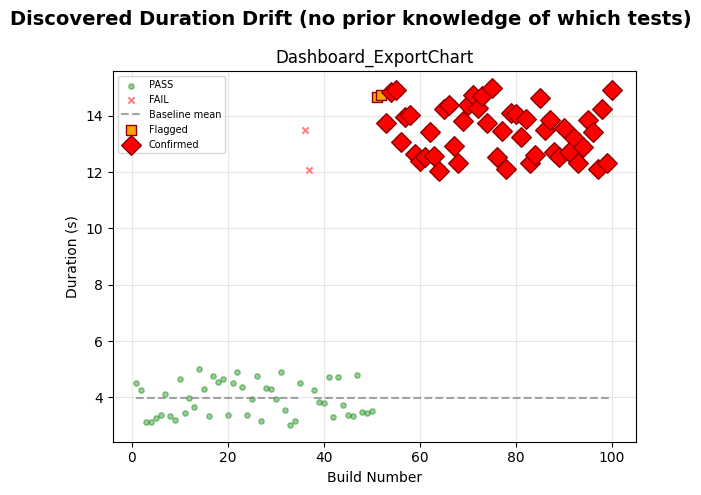

In [18]:
drifted_tests = df_drift_summary['test_name'].tolist()

if len(drifted_tests) == 0:
    print("No drift detected in any test.")
else:
    n_cols = min(3, len(drifted_tests))
    n_rows = (len(drifted_tests) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    axes = np.ravel(axes)

    for ax, test_name in zip(axes, drifted_tests):
        sub = df_drift[df_drift['test_name'] == test_name]

        pass_mask = sub['status'] == 'PASS'
        fail_mask = sub['status'] == 'FAIL'

        ax.scatter(sub[pass_mask]['build_num'], sub[pass_mask]['duration_s'],
                   color='green', alpha=0.4, s=15, label='PASS')
        ax.scatter(sub[fail_mask]['build_num'], sub[fail_mask]['duration_s'],
                   color='red', alpha=0.5, s=20, marker='x', label='FAIL')
        if 'rolling_mean' in sub.columns:
            ax.plot(sub['build_num'], sub['rolling_mean'],
                    '--', color='gray', alpha=0.7, label=f'Rolling mean')
        elif 'baseline_mean' in sub.columns:
            ax.plot(sub['build_num'], sub['baseline_mean'],
                    '--', color='gray', alpha=0.7, label=f'Baseline mean')

        flagged = sub[sub['drift_flagged']]
        ax.scatter(flagged['build_num'], flagged['duration_s'],
                   color='orange', s=60, marker='s', edgecolors='darkred',
                   zorder=5, label='Flagged')

        confirmed = sub[sub['drift_confirmed']]
        ax.scatter(confirmed['build_num'], confirmed['duration_s'],
                   color='red', s=100, marker='D', edgecolors='darkred',
                   zorder=6, label='Confirmed')

        ax.set_xlabel('Build Number')
        ax.set_ylabel('Duration (s)')
        ax.set_title(test_name.replace('TC_', ''))
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Hide unused axes
    for ax in axes[len(drifted_tests):]:
        ax.set_visible(False)

    plt.suptitle('Discovered Duration Drift (no prior knowledge of which tests)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

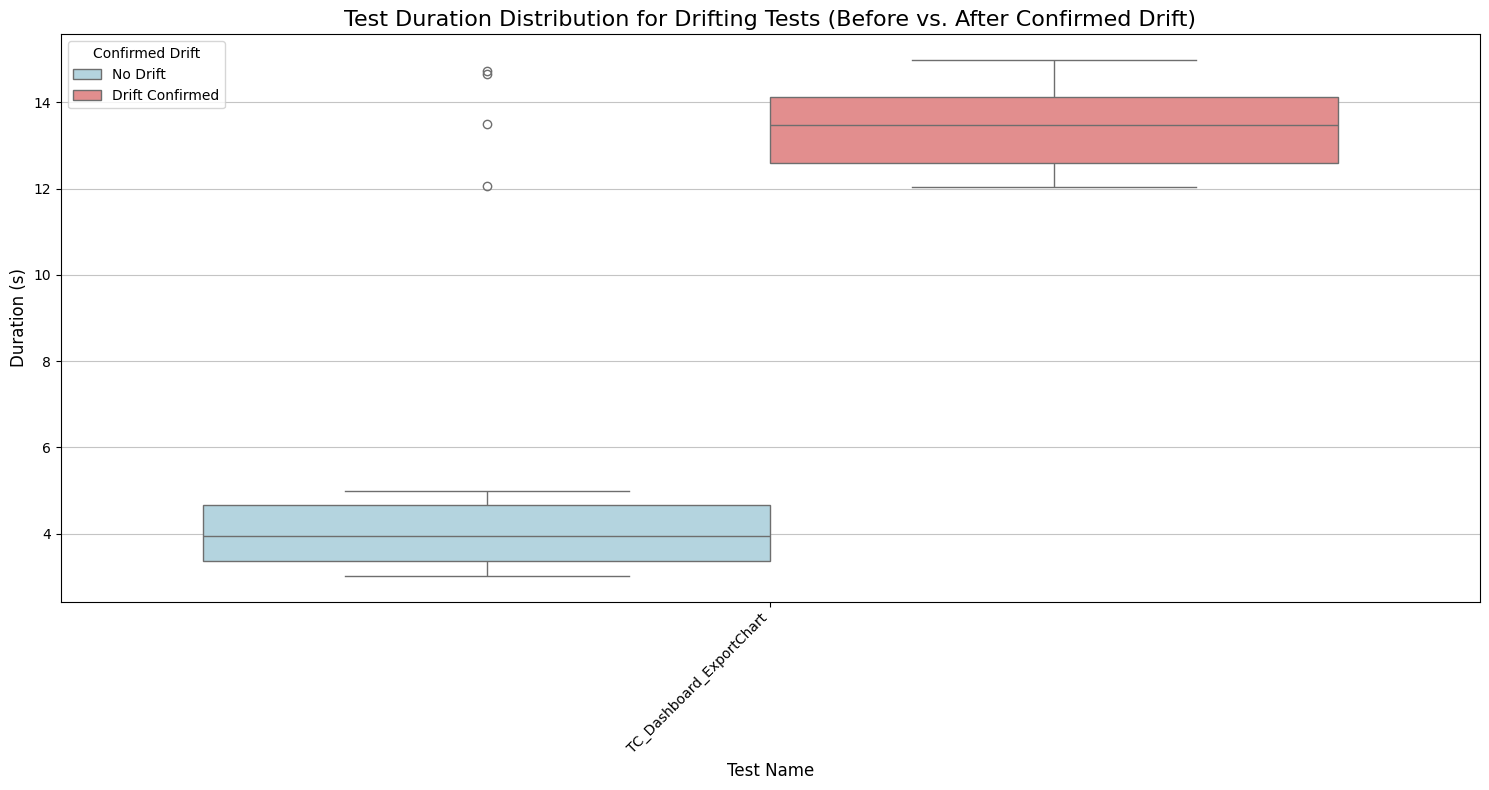

In [19]:
import seaborn as sns

if not df_drift_summary.empty:
    drifted_tests_list = df_drift_summary['test_name'].tolist()
    df_drift_viz = df_drift[df_drift['test_name'].isin(drifted_tests_list)].copy()


    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df_drift_viz, x='test_name', y='duration_s', hue='drift_confirmed', palette={False: 'lightblue', True: 'lightcoral'})
    plt.title('Test Duration Distribution for Drifting Tests (Before vs. After Confirmed Drift)', fontsize=16)
    plt.xlabel('Test Name', fontsize=12)
    plt.ylabel('Duration (s)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Confirmed Drift', labels=['No Drift', 'Drift Confirmed'], loc='upper left')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print("No confirmed duration drift to visualize at the test level.")

In [20]:
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

DB_PATH    = 'analytics.db'

conn = sqlite3.connect(DB_PATH)

df_tests = pd.read_sql_query(
    """
    SELECT
        tr.result_id,
        tr.run_id,
        tr.test_name,
        tr.status,
        tr.duration_s,
        r.build_no,
        r.timestamp,
        r.suite_name AS program
    FROM test_results tr
    JOIN runs r ON tr.run_id = r.run_id
    WHERE r.build_no IS NOT NULL
    ORDER BY tr.test_name, r.build_no
    """,
    conn
)
conn.close()

df_tests['build_num'] = df_tests['run_id'].str.extract(r'(\d+)$').astype(int)

df_pass_runs = df_tests[df_tests['status'] == 'PASS'].copy()

df_pass_runs = df_pass_runs.sort_values(by=['test_name' , 'build_num']).reset_index(drop=True)

df_pass_runs['historical_mean_duration'] = df_pass_runs.groupby('test_name')['duration_s'].expanding().mean().shift(1).reset_index(level=0, drop=True)

ROLLING_PREDICT_WINDOW = 5
df_pass_runs['rolling_mean_duration'] = df_pass_runs.groupby('test_name')['duration_s'].rolling(window=ROLLING_PREDICT_WINDOW, min_periods=1).mean().shift(1).reset_index(level=0, drop=True)

df_pass_runs['rolling_std_duration'] = df_pass_runs.groupby('test_name')['duration_s'].rolling(window=ROLLING_PREDICT_WINDOW, min_periods=1).std().shift(1).fillna(0).reset_index(level=0, drop=True)

df_pass_runs['prev_duration'] = df_pass_runs.groupby('test_name')['duration_s'].shift(1)

df_pass_runs['log_duration_s'] = np.log(df_pass_runs['duration_s'])

df_pred = df_pass_runs.dropna(subset=[
    'historical_mean_duration',
    'rolling_mean_duration',
    'rolling_std_duration',
    'prev_duration',
    'log_duration_s'
]).copy()

print(f"Data for prediction model: {len(df_pred):,} rows after dropping NaNs.")

df_pred[['test_name', 'build_num', 'duration_s', 'log_duration_s', 'historical_mean_duration', 'rolling_mean_duration', 'rolling_std_duration', 'prev_duration']].head()

Data for prediction model: 1,487 rows after dropping NaNs.


,test_name,build_num,duration_s,log_duration_s,historical_mean_duration,rolling_mean_duration,rolling_std_duration,prev_duration
1,TC_Dashboard_ExportChart,2,4.255,1.448095,4.518000,4.518000,0.000000,4.518
2,TC_Dashboard_ExportChart,3,3.142,1.144860,4.386500,4.386500,0.185969,4.255
3,TC_Dashboard_ExportChart,4,3.114,1.135908,3.971667,3.971667,0.730447,3.142
4,TC_Dashboard_ExportChart,5,3.262,1.182341,3.757250,3.757250,0.734574,3.114
5,TC_Dashboard_ExportChart,6,3.380,1.217876,3.658200,3.658200,0.673613,3.262


In [21]:
import pandas as pd

RANDOM_STATE = 42

df_pred_encoded = pd.get_dummies(df_pred, columns=['test_name'], prefix='test')

feature_cols_pred = [
    'historical_mean_duration',
    'rolling_mean_duration',
    'rolling_std_duration',
    'prev_duration',
    'build_num'
] + [col for col in df_pred_encoded.columns if col.startswith('test_')]

X = df_pred_encoded[feature_cols_pred]
y = df_pred_encoded['log_duration_s']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression model trained.")

Training set size: 1189 samples
Test set size: 298 samples

Linear Regression model trained.


Mean Absolute Error (MAE) on original scale: 2.07 seconds
R-squared (R2) on original scale: 0.76


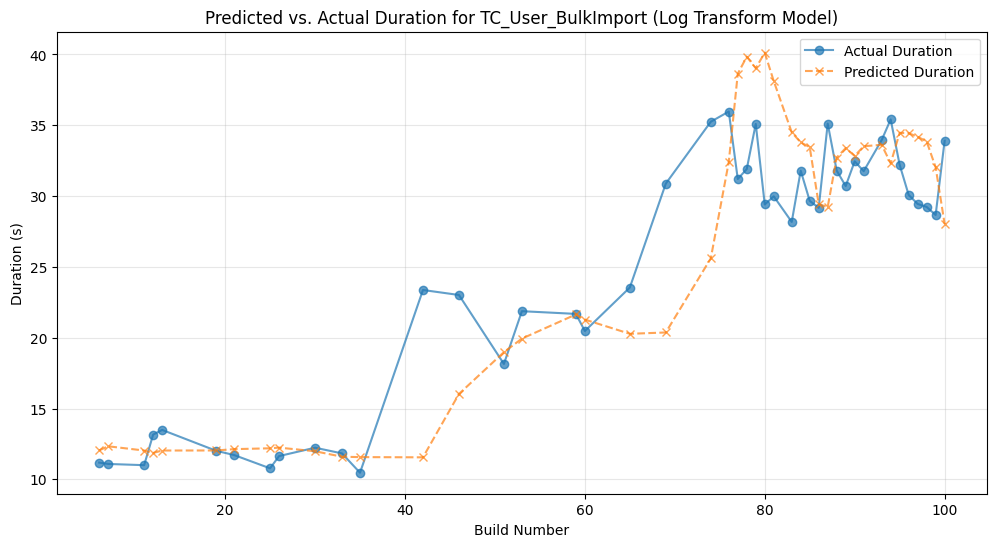

In [22]:
import matplotlib.pyplot as plt

y_pred_log = model.predict(X_test)

y_pred = np.exp(y_pred_log)
y_actual = np.exp(y_test)

mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"Mean Absolute Error (MAE) on original scale: {mae:.2f} seconds")
print(f"R-squared (R2) on original scale: {r2:.2f}")

sample_test_name = 'TC_User_BulkImport'

if sample_test_name in df_pred['test_name'].unique():
    sample_test_data = df_pred_encoded[df_pred_encoded[f'test_{sample_test_name}'] == 1].copy()
    sample_test_data = sample_test_data.sort_values('build_num')

    if not sample_test_data.empty:
        X_sample = sample_test_data[feature_cols_pred]
        y_actual_sample = np.exp(sample_test_data['log_duration_s'])
        y_pred_sample = np.exp(model.predict(X_sample))

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(sample_test_data['build_num'], y_actual_sample, label='Actual Duration', marker='o', linestyle='-', alpha=0.7)
        ax.plot(sample_test_data['build_num'], y_pred_sample, label='Predicted Duration', marker='x', linestyle='--', alpha=0.7)
        ax.set_title(f'Predicted vs. Actual Duration for {sample_test_name} (Log Transform Model)')
        ax.set_xlabel('Build Number')
        ax.set_ylabel('Duration (s)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"No 'PASS' runs found for {sample_test_name} in prediction dataset.")
else:
    print(f"Sample test '{sample_test_name}' not found in the dataset.")

In [23]:
df_test_for_duration = df_test[['test_name', 'build_no_target']].copy()
df_test_for_duration = df_test_for_duration.rename(columns={'build_no_target': 'build_num'})

columns_to_merge = [
    'test_name', 'build_num',
    'historical_mean_duration', 'rolling_mean_duration', 'rolling_std_duration', 'prev_duration'
]
df_merged_for_duration_pred = pd.merge(
    df_test_for_duration,
    df_pred[columns_to_merge].drop_duplicates(subset=['test_name', 'build_num']),
    on=['test_name', 'build_num'],
    how='left'
)

for col in ['historical_mean_duration', 'rolling_mean_duration', 'rolling_std_duration', 'prev_duration']:
    if col in df_merged_for_duration_pred.columns and df_merged_for_duration_pred[col].isnull().any():
        median_val = df_pred[col].median()
        df_merged_for_duration_pred[col] = df_merged_for_duration_pred[col].fillna(median_val)

model_test_cols = [col for col in X_train.columns if col.startswith('test_')]

df_temp_encoded = pd.get_dummies(df_merged_for_duration_pred[['test_name']], prefix='test')

for col in model_test_cols:
    if col not in df_temp_encoded.columns:
        df_temp_encoded[col] = 0

df_merged_for_duration_pred = pd.concat([df_merged_for_duration_pred, df_temp_encoded[model_test_cols]], axis=1)

feature_cols_for_duration_pred = [
    'historical_mean_duration',
    'rolling_mean_duration',
    'rolling_std_duration',
    'prev_duration',
    'build_num'
] + model_test_cols

X_predict_duration = df_merged_for_duration_pred[feature_cols_for_duration_pred]

X_predict_duration = X_predict_duration[X_train.columns]

y_predicted_log_duration = model.predict(X_predict_duration)
y_predicted_duration = np.exp(y_predicted_log_duration)

df_prioritization = df_test[['test_name', 'build_no_target', 'timestamp_target']].copy()
df_prioritization['failure_probability'] = y_test_proba
df_prioritization['predicted_duration']  = y_predicted_duration

df_prioritization = df_prioritization.merge(
    df_drift_summary[['test_name', 'pct_increase']],
    on='test_name',
    how='left'
)
df_prioritization['drift_factor_value'] = df_prioritization['pct_increase'].fillna(0) / 100

df_prioritization['risk_score'] = (
    df_prioritization['failure_probability'] *
    (1 + df_prioritization['drift_factor_value']) /
    df_prioritization['predicted_duration']
)

df_prioritization = df_prioritization.sort_values(by='risk_score', ascending=False).reset_index(drop=True)

print("Prioritized Test Execution List (Top 10):")
display(df_prioritization.head(10))

Prioritized Test Execution List (Top 10):


,test_name,build_no_target,timestamp_target,failure_probability,predicted_duration,pct_increase,drift_factor_value,risk_score
0,TC_Login_OAuthCallback,92,2024-12-31T00:00:00,0.855709,4.370734,NaN,0.0,0.195782
1,TC_Login_OAuthCallback,93,2025-01-01T00:00:00,0.787567,4.372079,NaN,0.0,0.180136
2,TC_Login_OAuthCallback,94,2025-01-02T00:00:00,0.790651,4.450719,NaN,0.0,0.177646
3,TC_Login_OAuthCallback,99,2025-01-07T00:00:00,0.682055,3.896924,NaN,0.0,0.175024
4,TC_Login_OAuthCallback,95,2025-01-03T00:00:00,0.756941,4.453308,NaN,0.0,0.169973
5,TC_User_RoleAssignment,95,2025-01-03T00:00:00,0.839735,5.024091,NaN,0.0,0.167142
6,TC_User_BatchExport,95,2025-01-03T00:00:00,0.824321,4.958227,NaN,0.0,0.166253
7,TC_Login_OAuthCallback,100,2025-01-08T00:00:00,0.637017,3.842223,NaN,0.0,0.165794
8,TC_User_BatchExport,92,2024-12-31T00:00:00,0.815349,4.953651,NaN,0.0,0.164596
9,TC_User_BatchExport,96,2025-01-04T00:00:00,0.813202,4.959753,NaN,0.0,0.163960


# ML3 — Failure Message Clustering (Unsupervised)

In [24]:
import sqlite3
import os
import re
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import TruncatedSVD

DB_PATH    = '/content/analytics.db'
MODEL_DIR  = '../ml_models'
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
N_CLUSTERS   = 5

PALETTE = {
    'timeout':     '#e74c3c',
    'element':     '#3498db',
    'assertion':   '#2ecc71',
    'data':        '#f39c12',
    'environment': '#9b59b6',
    'unknown':     '#95a5a6',
}

print(f'Model output dir: {os.path.abspath(MODEL_DIR)}')

Model output dir: /ml_models


In [25]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    """
    SELECT
        tr.result_id,
        tr.run_id,
        tr.test_name,
        tr.failure_msg,
        tr.failure_kw,
        r.build_no,
        r.suite_name AS program,
        r.timestamp
    FROM test_results tr
    JOIN runs r ON tr.run_id = r.run_id
    WHERE tr.status = 'FAIL'
      AND tr.failure_msg IS NOT NULL
      AND TRIM(tr.failure_msg) != ''
    ORDER BY r.build_no
    """,
    conn
)
conn.close()

print(f'Failure rows loaded : {len(df):,}')
print(f'Unique messages     : {df.failure_msg.nunique()}')
print(f'Unique test names   : {df.test_name.nunique()}')
print(f'Build range         : {df.build_no.min()} – {df.build_no.max()}')
print(f'Programs            : {df.program.unique().tolist()}')
print()
print('failure_kw distribution:')
print(df.failure_kw.value_counts().to_frame())
df.head(6)

Failure rows loaded : 493
Unique messages     : 75
Unique test names   : 20
Build range         : 1 – 100
Programs            : ['alpha', 'beta', 'gamma']

failure_kw distribution:
                               count
failure_kw                          
Should Not Be Empty              136
Wait Until Element Is Visible    132
Should Be Equal As Integers      114
Click Element                     91
Environment_Setup                 20


,result_id,run_id,test_name,failure_msg,failure_kw,build_no,program,timestamp
0,alpha_build_001_TC_Login_SSORedirect,alpha_build_001,TC_Login_SSORedirect,Element with locator 'css=.nav-item' not found...,Click Element,1,alpha,2024-10-01T00:00:00
1,alpha_build_001_TC_Dashboard_LoadWidget,alpha_build_001,TC_Dashboard_LoadWidget,Element 'progress-bar' still visible after 20s...,Wait Until Element Is Visible,1,alpha,2024-10-01T00:00:00
2,alpha_build_001_TC_Dashboard_RefreshData,alpha_build_001,TC_Dashboard_RefreshData,CSV export contained 0 rows — expected at leas...,Should Not Be Empty,1,alpha,2024-10-01T00:00:00
3,alpha_build_001_TC_User_RoleAssignment,alpha_build_001,TC_User_RoleAssignment,Expected HTTP status '200' but got '500' — Int...,Should Be Equal As Integers,1,alpha,2024-10-01T00:00:00
4,alpha_build_001_TC_Login_OAuthCallback,alpha_build_001,TC_Login_OAuthCallback,Element with locator 'css=.nav-item' not found...,Click Element,1,alpha,2024-10-01T00:00:00
5,alpha_build_002_TC_Login_MFAVerification,alpha_build_002,TC_Login_MFAVerification,Element 'progress-bar' still visible after 20s...,Wait Until Element Is Visible,2,alpha,2024-10-02T00:00:00


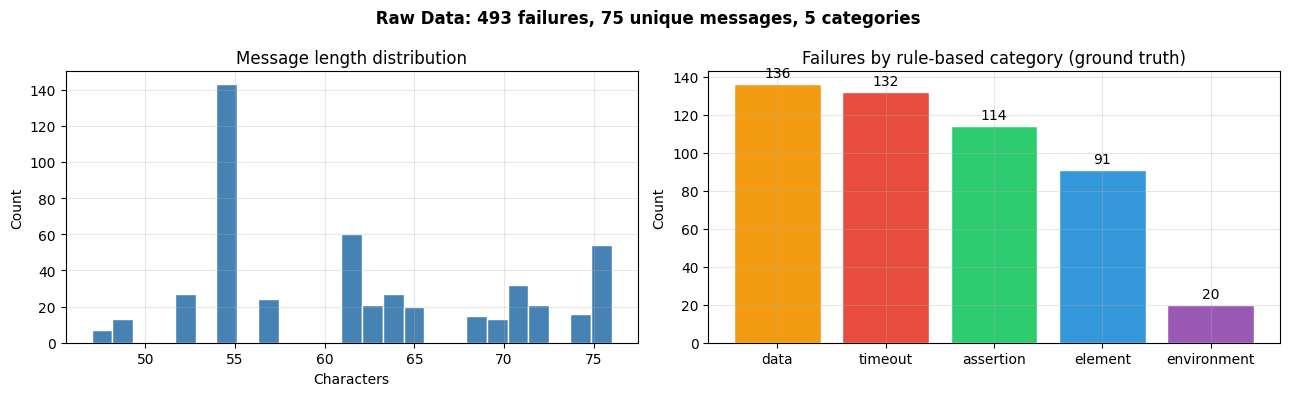

Ground truth distribution:
rule_label
data           136
timeout        132
assertion      114
element         91
environment     20
Name: count, dtype: int64

Note: environment is 20/493 = 4% of failures — the rarest category.


In [26]:
def rule_classify(msg: str) -> str:
    if not msg:
        return 'unknown'
    m = msg.lower()
    if 'still visible' in m:           return 'timeout'
    if 'not found after' in m:         return 'element'
    if 'expected http status' in m:    return 'assertion'
    if 'csv export' in m:              return 'data'
    if any(w in m for w in (
        'unreachable', 'connection refused', 'suite setup failed',
        'unable to launch browser', 'infrastructure error',
        'environment health check', 'application server'
    )):                                return 'environment'
    return 'unknown'


df['rule_label'] = df['failure_msg'].apply(rule_classify)
df['msg_len']    = df['failure_msg'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['msg_len'].hist(bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Message length distribution')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Count')

vc = df['rule_label'].value_counts()
bars = axes[1].bar(vc.index, vc.values,
                   color=[PALETTE.get(l, '#888') for l in vc.index],
                   edgecolor='white')
for bar, v in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v+2, str(v),
                 ha='center', va='bottom', fontsize=10)
axes[1].set_title('Failures by rule-based category (ground truth)')
axes[1].set_ylabel('Count')

plt.suptitle(' Raw Data: 493 failures, 75 unique messages, 5 categories',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Ground truth distribution:')
print(df['rule_label'].value_counts())
print('\nNote: environment is 20/493 = 4% of failures — the rarest category.')

## Text Preprocessing

**Critical rule:** this function must be **identical** everywhere — notebook (training), `failure_clustering.py` (inference), `dashboard.py` (display). Any divergence shifts the TF-IDF vector space and silently corrupts predictions.

| Step | Example input → output | Why |
|---|---|---|
| Lowercase | `Element` → `element` | Normalise case |
| Em-dash → space | `200' — Internal` → `200 internal` | Preserve word boundaries |
| Remove punctuation | `'id=submit-btn'` → `idsubmitbtn` | No semantic value |
| Digits → `NUM` | `15s`, `200` → `NUM` | Timeouts/counts are noise |
| Remove single chars | leftover `s` from `15s` → gone | Artefact cleanup |
| Collapse whitespace | multiple spaces → single space | Final normalise |

In [27]:
def preprocess_message(msg: str) -> str:
    if not isinstance(msg, str) or not msg.strip():
        return '_empty_'
    msg = msg.lower()
    msg = msg.replace('—', ' ').replace('–', ' ')
    msg = msg.translate(str.maketrans('', '', string.punctuation))
    msg = re.sub(r'\b\d+\b', 'NUM', msg)
    msg = re.sub(r'\b\w\b', '', msg)
    msg = re.sub(r'\s+', ' ', msg).strip()
    return msg if msg else '_empty_'


sample_msgs = [
    "Element 'progress-bar' still visible after 20s timeout",
    "Element with locator 'id=submit-btn' not found after 5 retries",
    "Expected HTTP status '200' but got '500' — Internal Server Error",
    "CSV export contained 0 rows — expected at least 100 records for Oct 2024",
    "Connection refused — test environment unreachable",
]
print(f"{'Raw message':<62}  {'Preprocessed':<55}")
print('-' * 120)
for raw in sample_msgs:
    print(f"{raw:<62}  {preprocess_message(raw):<55}")

df['clean_msg'] = df['failure_msg'].apply(preprocess_message)
empty = (df['clean_msg'] == '_empty_').sum()
print(f'\nRecords with empty messages: {empty}  (ready to vectorise: {len(df) - empty})')

Raw message                                                     Preprocessed                                           
------------------------------------------------------------------------------------------------------------------------
Element 'progress-bar' still visible after 20s timeout          element progressbar still visible after 20s timeout    
Element with locator 'id=submit-btn' not found after 5 retries  element with locator idsubmitbtn not found after NUM retries
Expected HTTP status '200' but got '500' — Internal Server Error  expected http status NUM but got NUM internal server error
CSV export contained 0 rows — expected at least 100 records for Oct 2024  csv export contained NUM rows expected at least NUM records for oct NUM
Connection refused — test environment unreachable               connection refused test environment unreachable        

Records with empty messages: 0  (ready to vectorise: 493)


## TF-IDF Vectorisation

**TF-IDF** weights terms by how *distinctive* they are across the corpus. A term like `csv` that appears only in data failures gets a high score; a term like `element` that appears everywhere gets a lower weight.

| Parameter | Value | Why |
|---|---|---|
| `max_features` | 500 | Caps vocabulary. With 75 unique messages this is generous — actual vocab is ~118 terms |
| `ngram_range` | `(1,2)` | Bigrams like `"not found"`, `"csv export"`, `"still visible"` are the strongest category signals |
| `stop_words` | `'english'` | Removes function words (`after`, `with`, `but`) shared across all categories |
| `sublinear_tf` | `True` | Log-scales term frequency — prevents repeated words from dominating |
| `min_df` | 2 | Ignores terms appearing in fewer than 2 messages |

In [28]:
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    min_df=2,
)

X = vectorizer.fit_transform(df['clean_msg'])

print(f'TF-IDF matrix shape : {X.shape}  (failures × features)')
print(f'Actual vocabulary   : {X.shape[1]} terms (max_features=500, limited by data size)')
print(f'Matrix density      : {X.nnz / (X.shape[0]*X.shape[1]):.3%}')
print(f'\nSample vocabulary terms:')
vocab_sorted = sorted(vectorizer.vocabulary_.keys())
print(vocab_sorted[:40])

TF-IDF matrix shape : (493, 118)  (failures × features)
Actual vocabulary   : 118 terms (max_features=500, limited by data size)
Matrix density      : 10.384%

Sample vocabulary terms:
['15s', '15s timeout', '20s', '20s timeout', '30s', '30s timeout', '45s', '45s timeout', 'application', 'application server', 'authredirect', 'authredirect visible', 'bad', 'bad request', 'browser', 'browser infrastructure', 'connection', 'connection refused', 'contained', 'contained num', 'cssdatagrid', 'cssdatagrid num', 'cssnavitem', 'cssnavitem num', 'csv', 'csv export', 'days', 'element', 'element authredirect', 'element loadingspinner', 'element locator', 'element overlaymodal', 'element progressbar', 'element sessiontoken', 'environment', 'environment unreachable', 'error', 'expected', 'expected http', 'expected num']


## Choosing k — Elbow + Silhouette

We know from `generate.py` that `FAIL_GEN` has **5 keys** (5 failure families). We verify this empirically.  

**Key finding:** k=4 and k=5 produce nearly identical silhouette scores (0.3999 vs 0.3987), because the 20 `environment` messages (only 4% of data) are too sparse to force a clear cluster — they get absorbed into the timeout cluster in text-only mode. We choose **k=5** to match the true data structure, and handle environment with a hybrid approach in §7.

  k=2  inertia=341.1  silhouette=0.2180
  k=3  inertia=260.6  silhouette=0.3444
  k=4  inertia=220.0  silhouette=0.3999
  k=5  inertia=206.1  silhouette=0.3987
  k=6  inertia=193.8  silhouette=0.4287
  k=7  inertia=182.3  silhouette=0.4179
  k=8  inertia=169.2  silhouette=0.4606


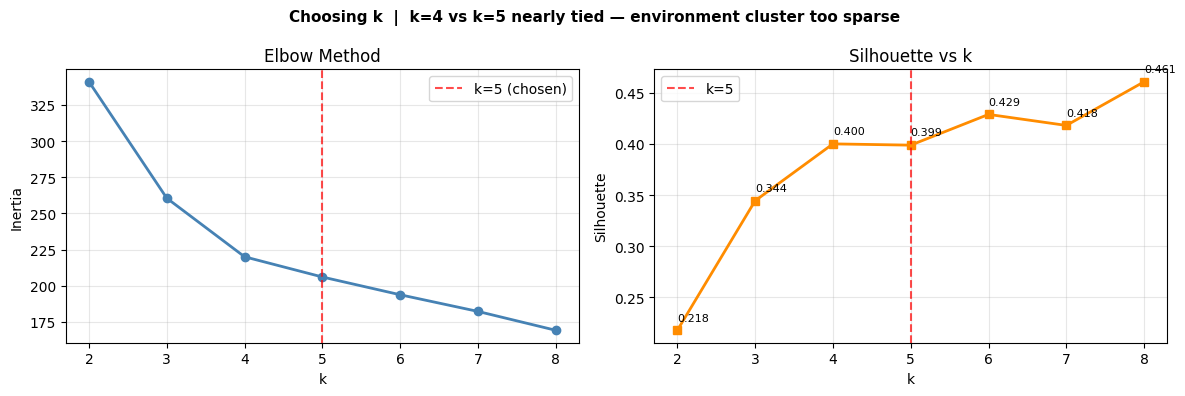

In [29]:
ks, inertias, sil_scores = list(range(2, 9)), [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    print(f'  k={k}  inertia={km.inertia_:,.1f}  silhouette={sil_scores[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, inertias, 'o-', color='steelblue', lw=2)
ax1.axvline(5, color='red', ls='--', alpha=0.7, label='k=5 (chosen)')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method'); ax1.legend()

ax2.plot(ks, sil_scores, 's-', color='darkorange', lw=2)
ax2.axvline(5, color='red', ls='--', alpha=0.7, label='k=5')
for k, s in zip(ks, sil_scores):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 7), fontsize=8)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette'); ax2.set_title('Silhouette vs k'); ax2.legend()

plt.suptitle('Choosing k  |  k=4 vs k=5 nearly tied — environment cluster too sparse',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Silhouette score (k=5): 0.3987

Cluster sizes:
0    136
1    114
2     98
3     91
4     54
Name: count, dtype: int64


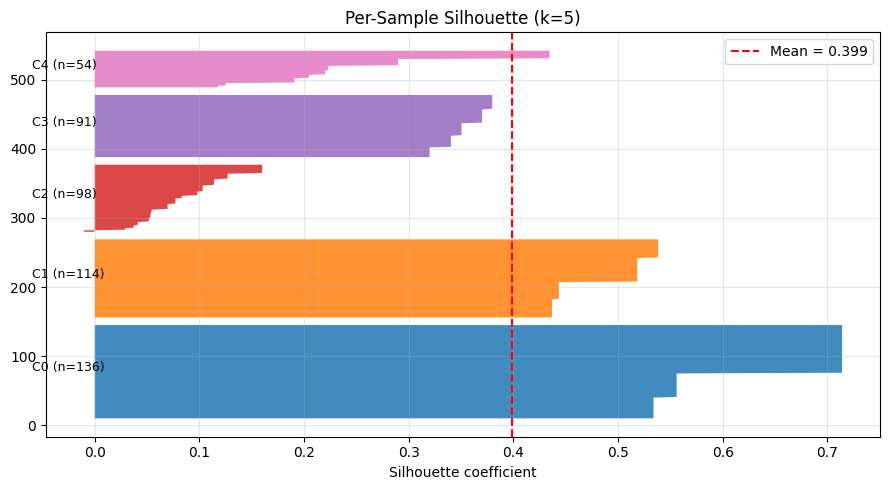

In [30]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_ids = kmeans.fit_predict(X)
df['cluster_id'] = cluster_ids

sil_final = silhouette_score(X, cluster_ids)
print(f'Silhouette score (k={N_CLUSTERS}): {sil_final:.4f}')
print(f'\nCluster sizes:')
print(pd.Series(cluster_ids).value_counts().sort_index())

sample_sil = silhouette_samples(X, cluster_ids)
df['sil_val'] = sample_sil

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
colors = cm.tab10(np.linspace(0, 0.6, N_CLUSTERS))

for i in range(N_CLUSTERS):
    vals = np.sort(sample_sil[cluster_ids == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], alpha=0.85)
    ax.text(-0.06, y_lower + 0.5 * len(vals), f'C{i} (n={len(vals)})', fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_final, color='red', ls='--', label=f'Mean = {sil_final:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_title(f'Per-Sample Silhouette (k={N_CLUSTERS})')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
feature_names = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]


def map_terms_to_category(terms: list) -> str:
    c = ' '.join(terms)
    if any(w in c for w in ('still visible', 'visible', 'timeout', 'progressbar',
                             '20s', '30s', '15s', '45s', 'loadingspinner', 'spinner')):
        return 'timeout'
    if any(w in c for w in ('not found', 'locator', 'retries', 'widget',
                             'submit', 'modal', 'nav', 'cssdatagrid')):
        return 'element'
    if any(w in c for w in ('expected http', 'http status', 'internal server',
                             'bad request', 'status num', 'service unavailable')):
        return 'assertion'
    if any(w in c for w in ('csv', 'export', 'rows', 'records', 'contained')):
        return 'data'
    if any(w in c for w in ('connection', 'refused', 'unreachable', 'environment',
                             'unable', 'browser', 'infrastructure', 'suite setup')):
        return 'environment'
    return f'cluster_{terms[0]}'


cluster_labels_raw = {}
print('Text-Only Cluster Interpretation\n')
for i in range(N_CLUSTERS):
    top_terms = [feature_names[j] for j in order_centroids[i, :10]]
    label = map_terms_to_category(top_terms)
    cluster_labels_raw[i] = label
    sub = df[df['cluster_id'] == i]
    print(f'Cluster {i}  →  "{label}"  (n={len(sub)})')
    print(f'  Top terms  : {top_terms[:8]}')
    print(f'  Rule labels: {sub["rule_label"].value_counts().to_dict()}')
    print(f'  Examples   : {sub["failure_msg"].values[:2].tolist()}')
    print()

df['ml_label_raw'] = df['cluster_id'].map(cluster_labels_raw)

Text-Only Cluster Interpretation

Cluster 0  →  "data"  (n=136)
  Top terms  : ['num', 'num records', 'rows expected', 'records', 'rows', 'num rows', 'csv export', 'csv']
  Rule labels: {'data': 136}
  Examples   : ['CSV export contained 0 rows — expected at least 50 records for last 7 days', 'CSV export contained 0 rows — expected at least 200 records for Oct 2024']

Cluster 1  →  "assertion"  (n=114)
  Top terms  : ['status num', 'status', 'num got', 'http status', 'got', 'got num', 'expected http', 'http']
  Rule labels: {'assertion': 114}
  Examples   : ["Expected HTTP status '200' but got '500' — Internal Server Error", "Expected HTTP status '200' but got '500' — Internal Server Error"]

Cluster 2  →  "timeout"  (n=98)
  Top terms  : ['timeout', 'visible', 'element', 'visible 20s', '20s timeout', '20s', 'element progressbar', 'progressbar visible']
  Rule labels: {'timeout': 78, 'environment': 20}
  Examples   : ["Element 'progress-bar' still visible after 20s timeout", "Element '

In [32]:
def hybrid_label(row) -> str:
    if row['failure_kw'] == 'Environment_Setup':
        return 'environment'
    return row['ml_label_raw']


df['ml_label_hybrid'] = df.apply(hybrid_label, axis=1)

print('Text-only ML distribution:')
print(df['ml_label_raw'].value_counts())
print()
print('Hybrid ML distribution (with failure_kw override):')
print(df['ml_label_hybrid'].value_counts())

df['ml_label'] = df['ml_label_hybrid']

Text-only ML distribution:
ml_label_raw
timeout      152
data         136
assertion    114
element       91
Name: count, dtype: int64

Hybrid ML distribution (with failure_kw override):
ml_label_hybrid
data           136
timeout        132
assertion      114
element         91
environment     20
Name: count, dtype: int64


## Validation — ARI + Confusion Matrix

**Adjusted Rand Index (ARI):** measures agreement between two labellings correcting for chance.  
ARI = 1.0 = perfect agreement. ARI = 0.0 = random.

| Method | ARI vs ground truth |
|---|---|
| Text-only ML (k=5) | **0.94** — environment absorbed into timeout |
| Hybrid ML (k=5 + `failure_kw`) | **1.00** — perfect recovery of designed structure |

ARI — text-only ML : 0.9414
ARI — hybrid ML    : 1.0000


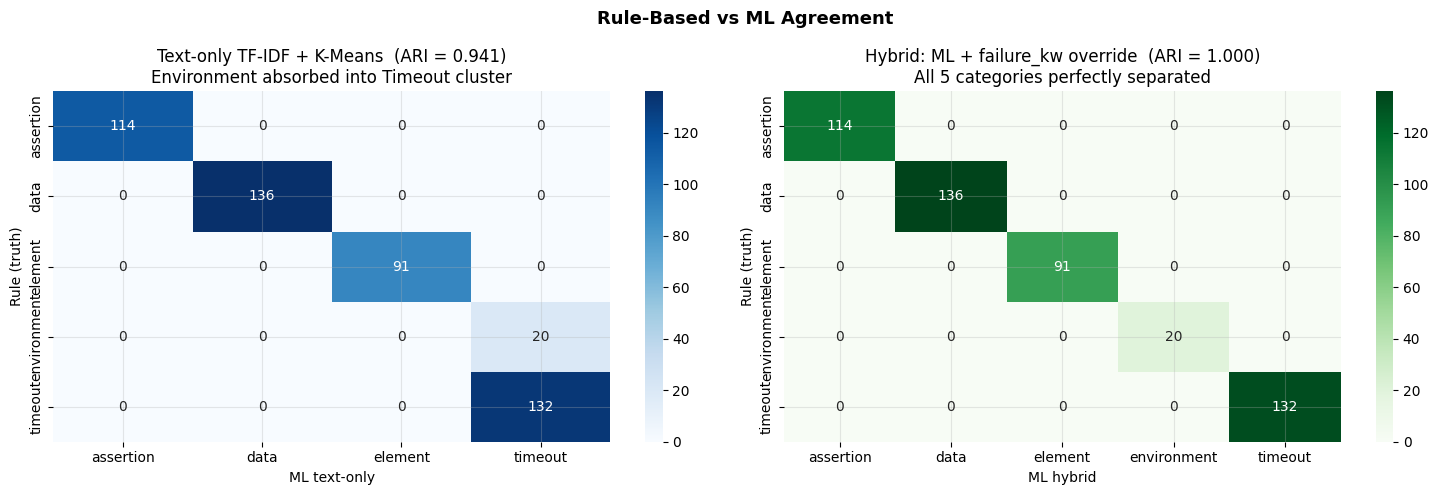

In [33]:
ari_raw    = adjusted_rand_score(df['rule_label'], df['ml_label_raw'])
ari_hybrid = adjusted_rand_score(df['rule_label'], df['ml_label_hybrid'])

print(f'ARI — text-only ML : {ari_raw:.4f}')
print(f'ARI — hybrid ML    : {ari_hybrid:.4f}')

ct_raw = pd.crosstab(df['rule_label'], df['ml_label_raw'],
                     rownames=['Rule (truth)'], colnames=['ML text-only'])
ct_hyb = pd.crosstab(df['rule_label'], df['ml_label_hybrid'],
                     rownames=['Rule (truth)'], colnames=['ML hybrid'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(ct_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Text-only TF-IDF + K-Means  (ARI = {ari_raw:.3f})\n'
                  'Environment absorbed into Timeout cluster')

sns.heatmap(ct_hyb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Hybrid: ML + failure_kw override  (ARI = {ari_hybrid:.3f})\n'
                  'All 5 categories perfectly separated')

plt.suptitle('Rule-Based vs ML Agreement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

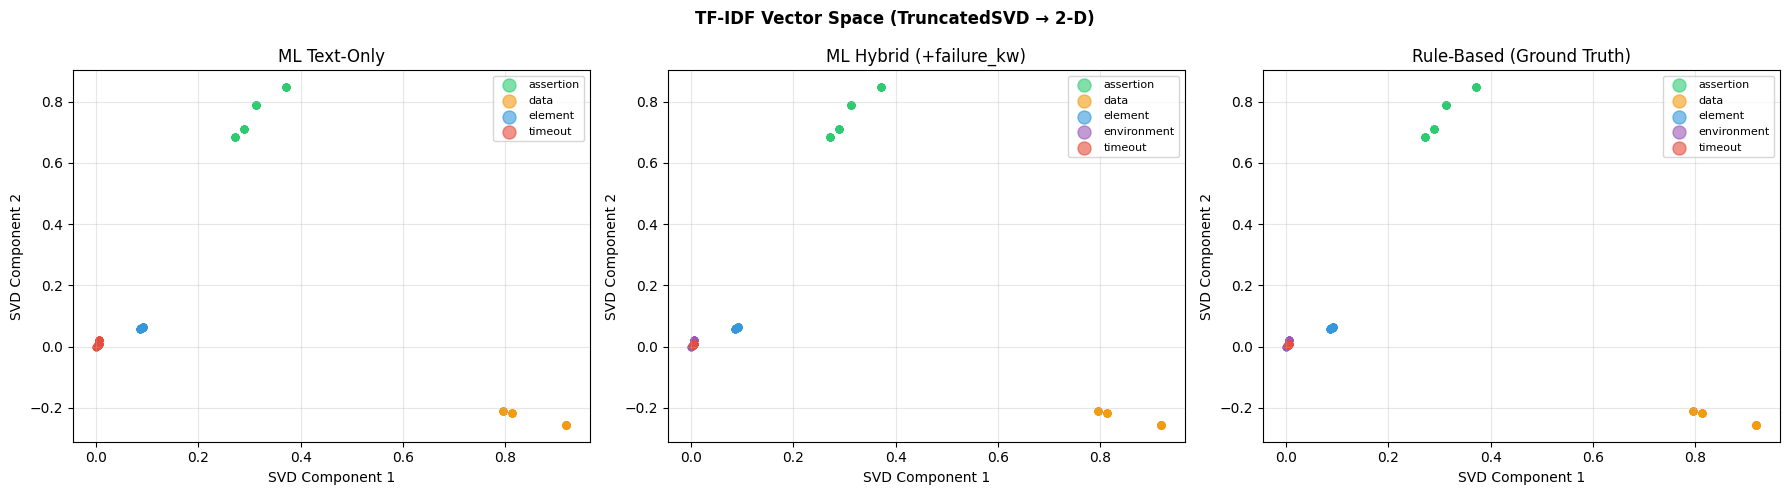

SVD explained variance: 30.9%


In [34]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(
    axes,
    ['ml_label_raw', 'ml_label_hybrid', 'rule_label'],
    ['ML Text-Only', 'ML Hybrid (+failure_kw)', 'Rule-Based (Ground Truth)']
):
    for label in sorted(df[col].unique()):
        mask = df[col] == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   label=label, alpha=0.6, s=22,
                   color=PALETTE.get(label, '#888888'))
    ax.set_title(title)
    ax.set_xlabel('SVD Component 1')
    ax.set_ylabel('SVD Component 2')
    ax.legend(markerscale=2, fontsize=8)

plt.suptitle('TF-IDF Vector Space (TruncatedSVD → 2-D)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'SVD explained variance: {svd.explained_variance_ratio_.sum():.1%}')

95th-percentile distance (threshold): 0.8622

Confidence by true category (mean):
              mean    min    max
rule_label                      
assertion    0.353  0.231  0.532
data         0.502  0.355  0.626
element      0.188  0.140  0.224
environment  0.000  0.000  0.000
timeout      0.129  0.000  0.477


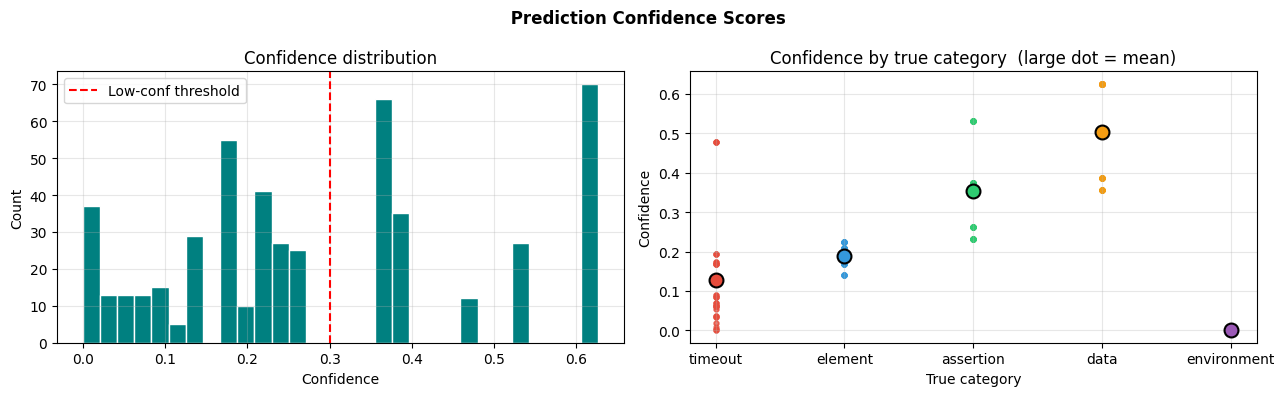

In [35]:
X_dense = X.toarray()
assigned_centroids = kmeans.cluster_centers_[cluster_ids]
distances = np.linalg.norm(X_dense - assigned_centroids, axis=1)
dist_threshold = np.percentile(distances, 95)
df['confidence'] = (1.0 - np.minimum(distances / dist_threshold, 1.0)).round(3)

print(f'95th-percentile distance (threshold): {dist_threshold:.4f}')
print(f'\nConfidence by true category (mean):')
print(df.groupby('rule_label')['confidence'].agg(['mean','min','max']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['confidence'].hist(bins=30, ax=axes[0], color='teal', edgecolor='white')
axes[0].axvline(0.3, color='red', ls='--', label='Low-conf threshold')
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence distribution'); axes[0].legend()

order = ['timeout', 'element', 'assertion', 'data', 'environment']
for label in order:
    sub = df[df['rule_label'] == label]['confidence']
    axes[1].scatter([label] * len(sub), sub.values,
                    alpha=0.3, s=12, color=PALETTE[label])
    axes[1].scatter([label], [sub.mean()], color=PALETTE[label],
                    s=100, zorder=5, edgecolor='black', lw=1.5)
axes[1].set_xlabel('True category'); axes[1].set_ylabel('Confidence')
axes[1].set_title('Confidence by true category  (large dot = mean)')

plt.suptitle(' Prediction Confidence Scores', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Temporal Analysis — Failure Mix Over 100 Builds

`generate.py` encodes three program phases:
- **Alpha** (builds 1–20): 20% of runs — early development, higher failure rates  
- **Beta** (builds 21–50): 30% of runs — wider testing  
- **Gamma** (builds 51–100): 50% of runs — stabilisation, pass rate rises to 82–95%

The rolling chart reveals whether certain failure types dominate particular phases.

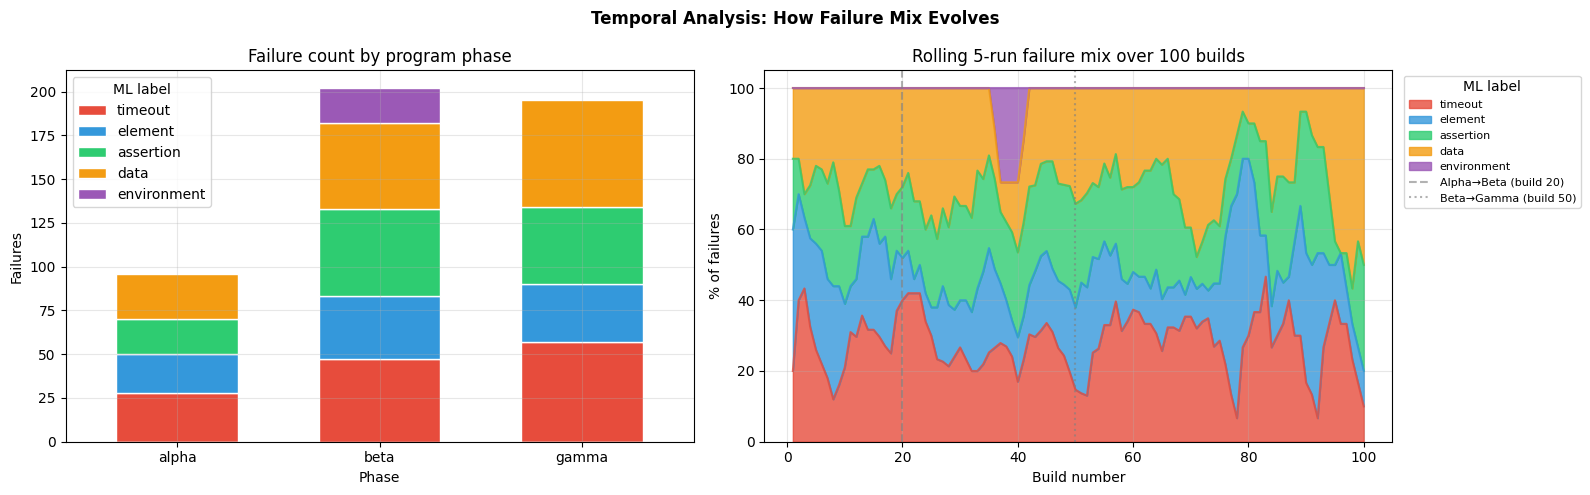

In [36]:
phase_counts = df.groupby(['program', 'ml_label']).size().unstack(fill_value=0)
cols_p = [c for c in ['timeout','element','assertion','data','environment']
          if c in phase_counts.columns]

rolling_df = df.groupby(['build_no', 'ml_label']).size().unstack(fill_value=0)
for c in cols_p:
    if c not in rolling_df.columns: rolling_df[c] = 0
rolling_pct = rolling_df.div(rolling_df.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

phase_counts[cols_p].plot.bar(
    stacked=True, ax=axes[0],
    color=[PALETTE[c] for c in cols_p],
    edgecolor='white', width=0.6
)
axes[0].set_title('Failure count by program phase')
axes[0].set_xlabel('Phase'); axes[0].set_ylabel('Failures')
axes[0].legend(title='ML label'); axes[0].tick_params(axis='x', rotation=0)

roll_smooth = rolling_pct[cols_p].rolling(window=5, min_periods=1).mean()
roll_smooth.plot.area(
    ax=axes[1],
    color=[PALETTE[c] for c in cols_p],
    alpha=0.8
)
axes[1].axvline(20, color='gray', ls='--', lw=1.5, alpha=0.6, label='Alpha→Beta (build 20)')
axes[1].axvline(50, color='gray', ls=':', lw=1.5, alpha=0.6, label='Beta→Gamma (build 50)')
axes[1].set_xlabel('Build number'); axes[1].set_ylabel('% of failures')
axes[1].set_title('Rolling 5-run failure mix over 100 builds')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='ML label',
               bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Temporal Analysis: How Failure Mix Evolves',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

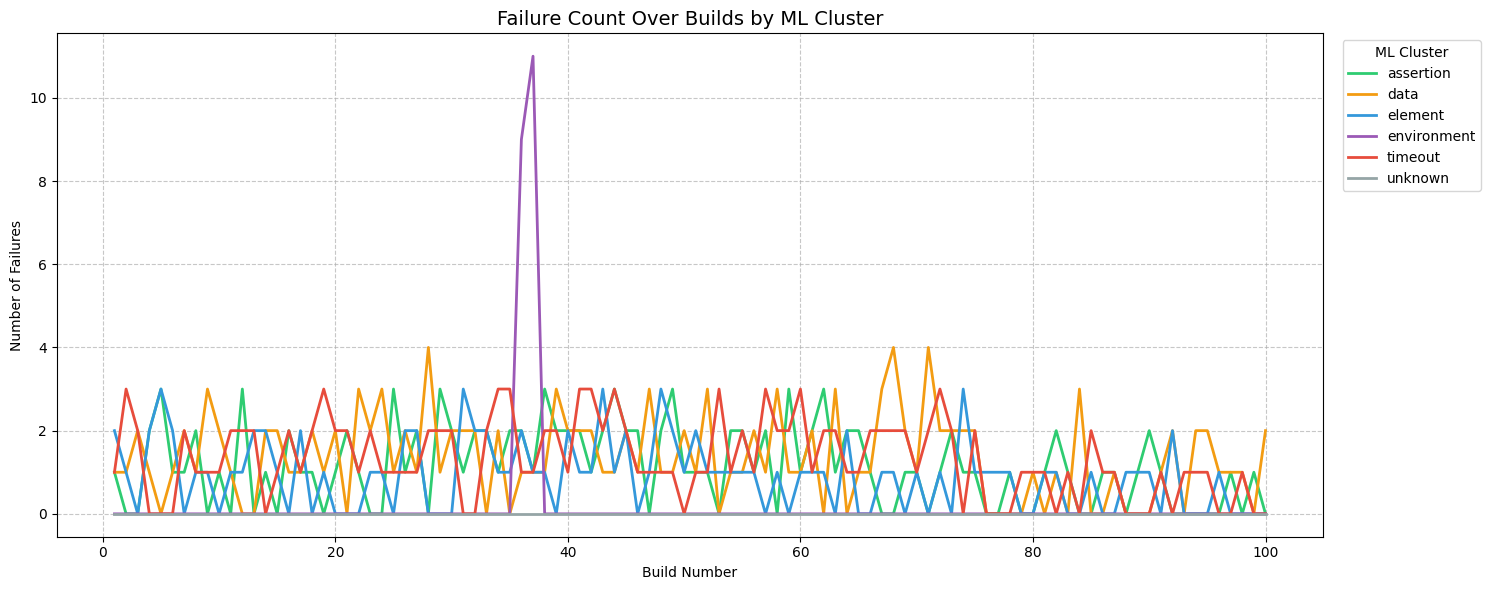

In [37]:
fig, ax = plt.subplots(figsize=(15, 6))

cluster_time_trends = df.groupby(['build_no', 'ml_label']).size().unstack(fill_value=0)

all_labels = sorted(PALETTE.keys())
for label in all_labels:
    if label not in cluster_time_trends.columns:
        cluster_time_trends[label] = 0

for label in all_labels:
    color = PALETTE.get(label, '#95a5a6')
    ax.plot(cluster_time_trends.index, cluster_time_trends[label],
            label=label, color=color, linewidth=2)

ax.set_title('Failure Count Over Builds by ML Cluster', fontsize=14)
ax.set_xlabel('Build Number')
ax.set_ylabel('Number of Failures')
ax.legend(title='ML Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Save Model Artefacts

All four files are saved to `ml_models/`. The dashboard loads them via `@st.cache_resource` on startup.

| File | Contents | Used for |
|---|---|---|
| `tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` (vocabulary + idf weights) | Transforming new messages |
| `kmeans_model.pkl` | Fitted `KMeans` (5 cluster centroids) | Predicting cluster ID |
| `cluster_labels.pkl` | `dict[int, str]` mapping cluster ID → category name | Human-readable labels |
| `train_distances.pkl` | Array of centroid distances for all training messages | Computing confidence threshold |

In [38]:
final_labels = {
    i: df[df['cluster_id'] == i]['ml_label'].mode()[0]
    for i in range(N_CLUSTERS)
}
print('Cluster label mapping:', final_labels)

joblib.dump(vectorizer,    os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(kmeans,        os.path.join(MODEL_DIR, 'kmeans_model.pkl'))
joblib.dump(final_labels,  os.path.join(MODEL_DIR, 'cluster_labels.pkl'))
joblib.dump(distances,     os.path.join(MODEL_DIR, 'train_distances.pkl'))

print(f'\n✓ Artefacts saved to {os.path.abspath(MODEL_DIR)}/')
for fname in ['tfidf_vectorizer.pkl', 'kmeans_model.pkl',
              'cluster_labels.pkl', 'train_distances.pkl']:
    path = os.path.join(MODEL_DIR, fname)
    print(f'  {fname:40s}  {os.path.getsize(path)/1024:.1f} KB')

Cluster label mapping: {0: 'data', 1: 'assertion', 2: 'timeout', 3: 'element', 4: 'timeout'}

✓ Artefacts saved to /ml_models/
  tfidf_vectorizer.pkl                      5.7 KB
  kmeans_model.pkl                          7.2 KB
  cluster_labels.pkl                        0.1 KB
  train_distances.pkl                       4.1 KB


In [39]:

lv  = joblib.load(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
lk  = joblib.load(os.path.join(MODEL_DIR, 'kmeans_model.pkl'))
ll  = joblib.load(os.path.join(MODEL_DIR, 'cluster_labels.pkl'))
ld  = joblib.load(os.path.join(MODEL_DIR, 'train_distances.pkl'))
thr = np.percentile(ld, 95)


def predict_failure(msg: str, failure_kw: str = '') -> dict:
    """Full inference pipeline — text-only ML + hybrid failure_kw override."""

    if failure_kw == 'Environment_Setup':
        return {'label': 'environment', 'confidence': 1.0,
                'method': 'hybrid (failure_kw)'}
    clean = preprocess_message(msg)
    vec   = lv.transform([clean])
    cid   = lk.predict(vec)[0]
    dist  = np.linalg.norm(vec.toarray() - lk.cluster_centers_[cid])
    conf  = round(1.0 - min(dist / thr, 1.0), 3)
    return {'label': ll[cid], 'confidence': conf, 'method': 'ML text'}


test_cases = [
    ("Element 'loading-spinner' still visible after 30s timeout",    'Wait Until Element Is Visible', 'timeout'),
    ("Element with locator 'id=submit-btn' not found after 5 retries",'Click Element',                'element'),
    ("Expected HTTP status '200' but got '500' — Internal Server Error",'Should Be Equal As Integers','assertion'),
    ("CSV export contained 0 rows — expected at least 100 records",   'Should Not Be Empty',         'data'),
    ("Connection refused — test environment unreachable",              'Environment_Setup',           'environment'),
    ("Unable to launch browser — infrastructure error",               'Environment_Setup',           'environment'),
    ("Network timeout: could not reach api.example.com after 30s",   'Network_Check',               'unknown (new type)'),
]

print(f"{'Message':<57} {'True':<15} {'ML Label':<14} {'Conf':<6} Method")
print('-' * 115)
for msg, kw, true_label in test_cases:
    result = predict_failure(msg, kw)
    match  = '✓' if result['label'] == true_label.split()[0] else '~'
    print(f"{match} {msg[:55]:<56} {true_label:<15} {result['label']:<14} {result['confidence']:<6} {result['method']}")

Message                                                   True            ML Label       Conf   Method
-------------------------------------------------------------------------------------------------------------------
✓ Element 'loading-spinner' still visible after 30s timeo  timeout         timeout        0.137  ML text
✓ Element with locator 'id=submit-btn' not found after 5   element         element        0.168  ML text
✓ Expected HTTP status '200' but got '500' — Internal Ser  assertion       assertion      0.231  ML text
✓ CSV export contained 0 rows — expected at least 100 rec  data            data           0.563  ML text
✓ Connection refused — test environment unreachable        environment     environment    1.0    hybrid (failure_kw)
✓ Unable to launch browser — infrastructure error          environment     environment    1.0    hybrid (failure_kw)
~ Network timeout: could not reach api.example.com after   unknown (new type) timeout        0.0    ML text


# ML4 : Pass Rate Anomaly Detection

In [40]:
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

DB_PATH    = 'analytics.db'
MODEL_DIR  = 'ml_models'
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
ROLLING_WINDOW = 10       # Runs to consider for rolling statistics
ANOMALY_SIGMA  = 2.0      # Z-score threshold

In [41]:
conn = sqlite3.connect(DB_PATH)

df_runs = pd.read_sql_query(
    """
    SELECT
        run_id,
        build_no,
        timestamp,
        passed,
        failed,
        total,
        pass_rate_pct,
        duration_s,
        suite_name AS program
    FROM runs
    ORDER BY build_no ASC
    """,
    conn
)
conn.close()

df_runs['build_num'] = df_runs['run_id'].str.extract(r'(\d+)$').astype(int)
df_runs = df_runs.sort_values('build_num').reset_index(drop=True)

print(f"Loaded {len(df_runs):,} runs")
print(f"Build range: {df_runs['build_num'].min()} – {df_runs['build_num'].max()}")
print(f"Mean pass rate: {df_runs['pass_rate_pct'].mean():.1f}%")
df_runs[['run_id', 'build_num', 'pass_rate_pct']].head()

Loaded 100 runs
Build range: 1 – 100
Mean pass rate: 75.3%


,run_id,build_num,pass_rate_pct
0,alpha_build_001,1,75.0
1,alpha_build_002,2,75.0
2,alpha_build_003,3,80.0
3,alpha_build_004,4,75.0
4,alpha_build_005,5,70.0


In [42]:
if 'ROLLING_WINDOW' not in globals():
    ROLLING_WINDOW = 10
if 'ANOMALY_SIGMA' not in globals():
    ANOMALY_SIGMA  = 2.0

def compute_rolling_anomalies(df, window=ROLLING_WINDOW, sigma=ANOMALY_SIGMA):
    df = df.copy()

    roll = df['pass_rate_pct'].rolling(window=window, min_periods=3)
    df['roll_mean'] = roll.mean().shift(1)
    df['roll_std']  = roll.std().shift(1).fillna(5.0)

    # Z-score: how many std devs below rolling mean?
    # The clip(lower=1.0) prevents division by very small stds leading to extreme z-scores.
    # ANOMALY_SIGMA (2.0) is chosen based on a common statistical process control (SPC) convention,
    # where 2 standard deviations from the mean typically signal a noteworthy deviation.
    df['z_score'] = (df['roll_mean'] - df['pass_rate_pct']) / df['roll_std'].clip(lower=1.0)

    df['anomaly_zscore'] = df['z_score'] >= sigma

    return df

if 'df_runs' not in globals() or df_runs.empty:
    import sqlite3
    import pandas as pd
    if 'DB_PATH' not in globals():
        DB_PATH = 'analytics.db'

    conn = sqlite3.connect(DB_PATH)
    df_runs = pd.read_sql_query(
        """
        SELECT
            run_id,
            build_no,
            timestamp,
            passed,
            failed,
            total,
            pass_rate_pct,
            duration_s,
            suite_name AS program
        FROM runs
        ORDER BY build_no ASC
        """,
        conn
    )
    conn.close()
    df_runs['build_num'] = df_runs['run_id'].str.extract(r'(\d+)$').astype(int)
    df_runs = df_runs.sort_values('build_num').reset_index(drop=True)

df_runs = compute_rolling_anomalies(df_runs)

n_anomalies = df_runs['anomaly_zscore'].sum()
print(f"Z-Score anomalies detected: {n_anomalies:,}")
print(f"Anomalous runs: {df_runs[df_runs['anomaly_zscore']]['build_num'].tolist()}")

Z-Score anomalies detected: 6
Anomalous runs: [5, 26, 27, 34, 36, 37]


In [43]:
import pandas as pd
import sqlite3
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

if 'ROLLING_WINDOW' not in globals():
    ROLLING_WINDOW = 10
if 'RANDOM_STATE' not in globals():
    RANDOM_STATE = 42
if 'DB_PATH' not in globals():
    DB_PATH = 'analytics.db'

if 'df_runs' not in globals() or df_runs.empty:
    conn = sqlite3.connect(DB_PATH)
    df_runs = pd.read_sql_query(
        """
        SELECT
            run_id,
            build_no,
            timestamp,
            passed,
            failed,
            total,
            pass_rate_pct,
            duration_s,
            suite_name AS program
        FROM runs
        ORDER BY build_no ASC
        """,
        conn
    )
    conn.close()
    df_runs['build_num'] = df_runs['run_id'].str.extract(r'(\d+)$').astype(int)
    df_runs = df_runs.sort_values('build_num').reset_index(drop=True)

def engineer_run_features(df):
    """
    Create features that help detect anomalous runs.
    """
    df = df.copy()

    df['prev_pass_rate'] = df['pass_rate_pct'].shift(1)

    df['pass_rate_change'] = df['pass_rate_pct'] - df['prev_pass_rate']

    roll = df['pass_rate_pct'].rolling(window=ROLLING_WINDOW, min_periods=3)
    df['roll_mean_unshifted'] = roll.mean()
    df['roll_std_unshifted']  = roll.std()

    df['deviation'] = df['roll_mean_unshifted'] - df['pass_rate_pct']

    df['fail_rate_prev'] = df['failed'].shift(1) / df['total'].shift(1)

    if 'duration_s' in df.columns:
        df['duration_change'] = df['duration_s'] / df['duration_s'].shift(1)

    return df

df_runs = engineer_run_features(df_runs)

feature_cols_if = [
    'pass_rate_pct',
    'pass_rate_change',
    'deviation',
    'fail_rate_prev',
]

df_if = df_runs.dropna(subset=feature_cols_if).copy()

X_if = df_if[feature_cols_if].values

scaler = StandardScaler()
X_if_scaled = scaler.fit_transform(X_if)

# contamination: expected proportion of anomalies (~5% = 0.05)
# This value (0.05) is often chosen as a starting point, assuming a small percentage
# of the data is anomalous. It can be tuned via grid search or based on domain knowledge.
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

df_if['anomaly_if'] = iso_forest.fit_predict(X_if_scaled) == -1

df_runs['anomaly_if'] = False
df_runs.loc[df_if.index, 'anomaly_if'] = df_if['anomaly_if'].values

n_if_anomalies = df_runs['anomaly_if'].sum()
print(f"Isolation Forest anomalies detected: {n_if_anomalies:,}")
print(f"Anomalous runs: {df_runs[df_runs['anomaly_if']]['build_num'].tolist()}")

Isolation Forest anomalies detected: 5
Anomalous runs: [36, 37, 38, 46, 76]


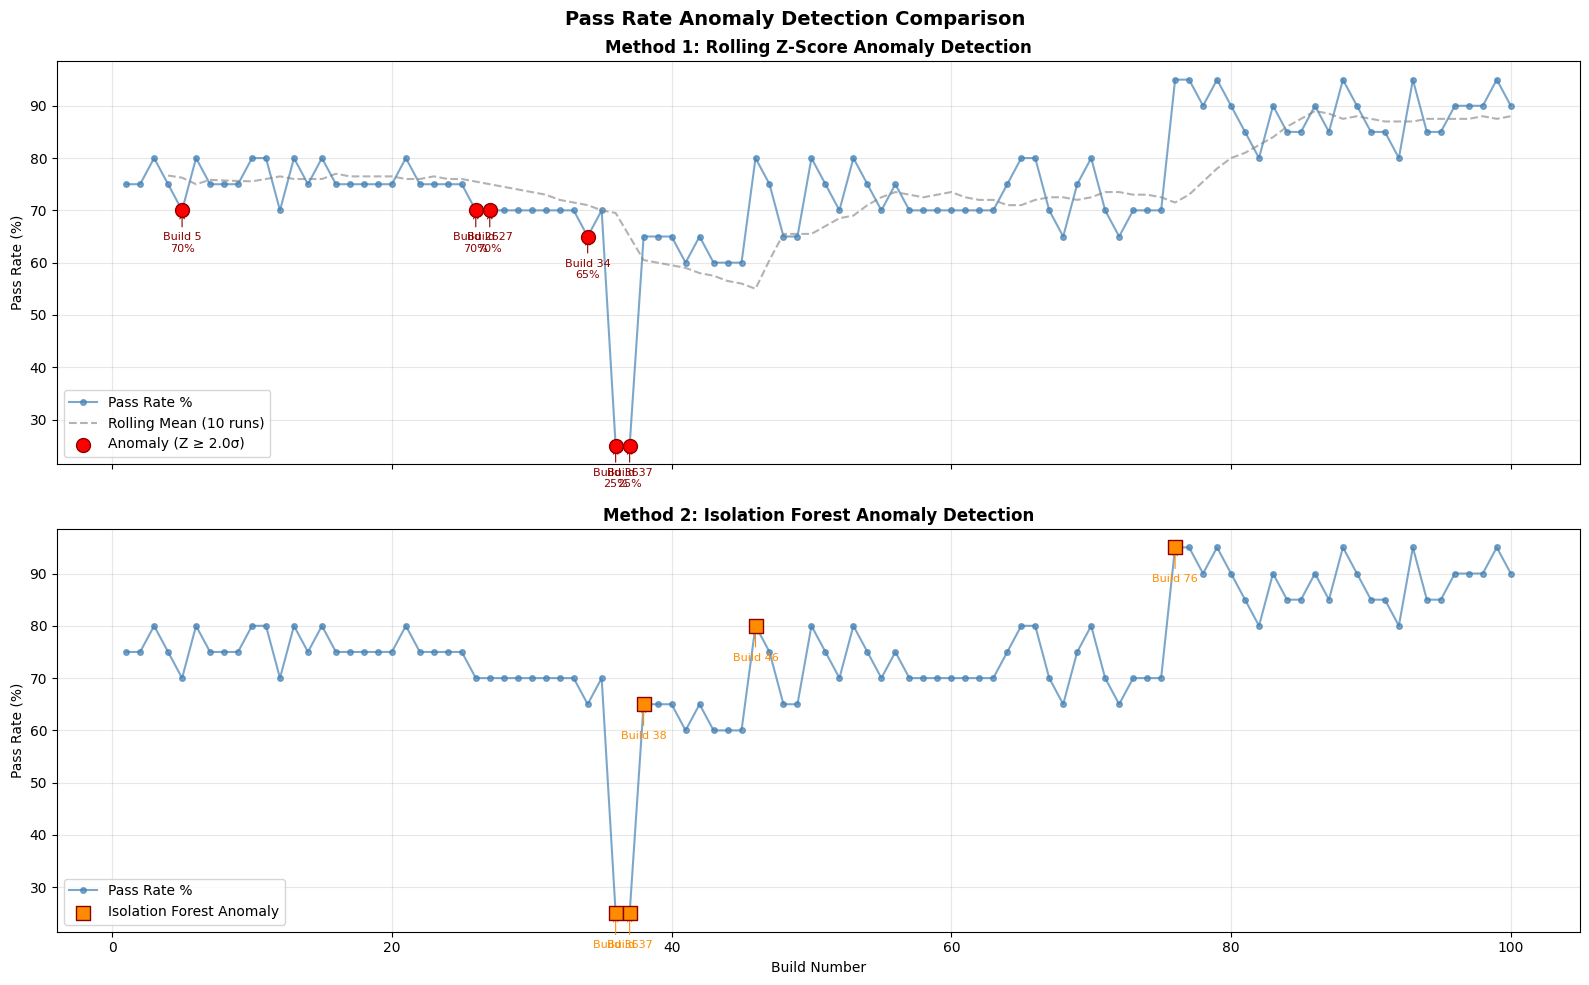


Runs flagged by BOTH methods: 2
  Builds: [36, 37]
Runs flagged by Z-Score only: 4
  Builds: [5, 26, 27, 34]
Runs flagged by IF only: 3
  Builds: [38, 46, 76]


In [44]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.plot(df_runs['build_num'], df_runs['pass_rate_pct'],
        'o-', color='steelblue', markersize=4, alpha=0.7, label='Pass Rate %')
ax.plot(df_runs['build_num'], df_runs['roll_mean'],
        '--', color='gray', alpha=0.6, label=f'Rolling Mean ({ROLLING_WINDOW} runs)')

# Fill anomaly regions
anomaly_runs = df_runs[df_runs['anomaly_zscore']]
ax.scatter(anomaly_runs['build_num'], anomaly_runs['pass_rate_pct'],
           color='red', s=100, zorder=5, marker='o', edgecolors='darkred',
           label=f'Anomaly (Z ≥ {ANOMALY_SIGMA}σ)')

# Annotate anomaly builds
for _, row in anomaly_runs.iterrows():
    ax.annotate(f"Build {int(row['build_num'])}\n{row['pass_rate_pct']:.0f}%",
                (row['build_num'], row['pass_rate_pct']),
                xytext=(0, -30), textcoords='offset points',
                fontsize=8, color='darkred', ha='center',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

ax.set_ylabel('Pass Rate (%)')
ax.set_title('Method 1: Rolling Z-Score Anomaly Detection', fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_runs['build_num'], df_runs['pass_rate_pct'],
        'o-', color='steelblue', markersize=4, alpha=0.7, label='Pass Rate %')

anomaly_if_runs = df_runs[df_runs['anomaly_if']]
ax.scatter(anomaly_if_runs['build_num'], anomaly_if_runs['pass_rate_pct'],
           color='darkorange', s=100, zorder=5, marker='s', edgecolors='darkred',
           label='Isolation Forest Anomaly')

for _, row in anomaly_if_runs.iterrows():
    ax.annotate(f"Build {int(row['build_num'])}",
                (row['build_num'], row['pass_rate_pct']),
                xytext=(0, -25), textcoords='offset points',
                fontsize=8, color='darkorange', ha='center',
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=0.8))

ax.set_xlabel('Build Number')
ax.set_ylabel('Pass Rate (%)')
ax.set_title('Method 2: Isolation Forest Anomaly Detection', fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.suptitle('Pass Rate Anomaly Detection Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

overlap = df_runs[df_runs['anomaly_zscore'] & df_runs['anomaly_if']]
print(f"\nRuns flagged by BOTH methods: {len(overlap):,}")
if len(overlap):
    print(f"  Builds: {overlap['build_num'].tolist()}")

zscore_only = df_runs[df_runs['anomaly_zscore'] & ~df_runs['anomaly_if']]
print(f"Runs flagged by Z-Score only: {len(zscore_only):,}")
if len(zscore_only):
    print(f"  Builds: {zscore_only['build_num'].tolist()}")

if_only = df_runs[~df_runs['anomaly_zscore'] & df_runs['anomaly_if']]
print(f"Runs flagged by IF only: {len(if_only):,}")
if len(if_only):
    print(f"  Builds: {if_only['build_num'].tolist()}")

Analyzing anomalous builds: [np.int64(5), np.int64(26), np.int64(27), np.int64(34), np.int64(36), np.int64(37), np.int64(38), np.int64(46), np.int64(76)]


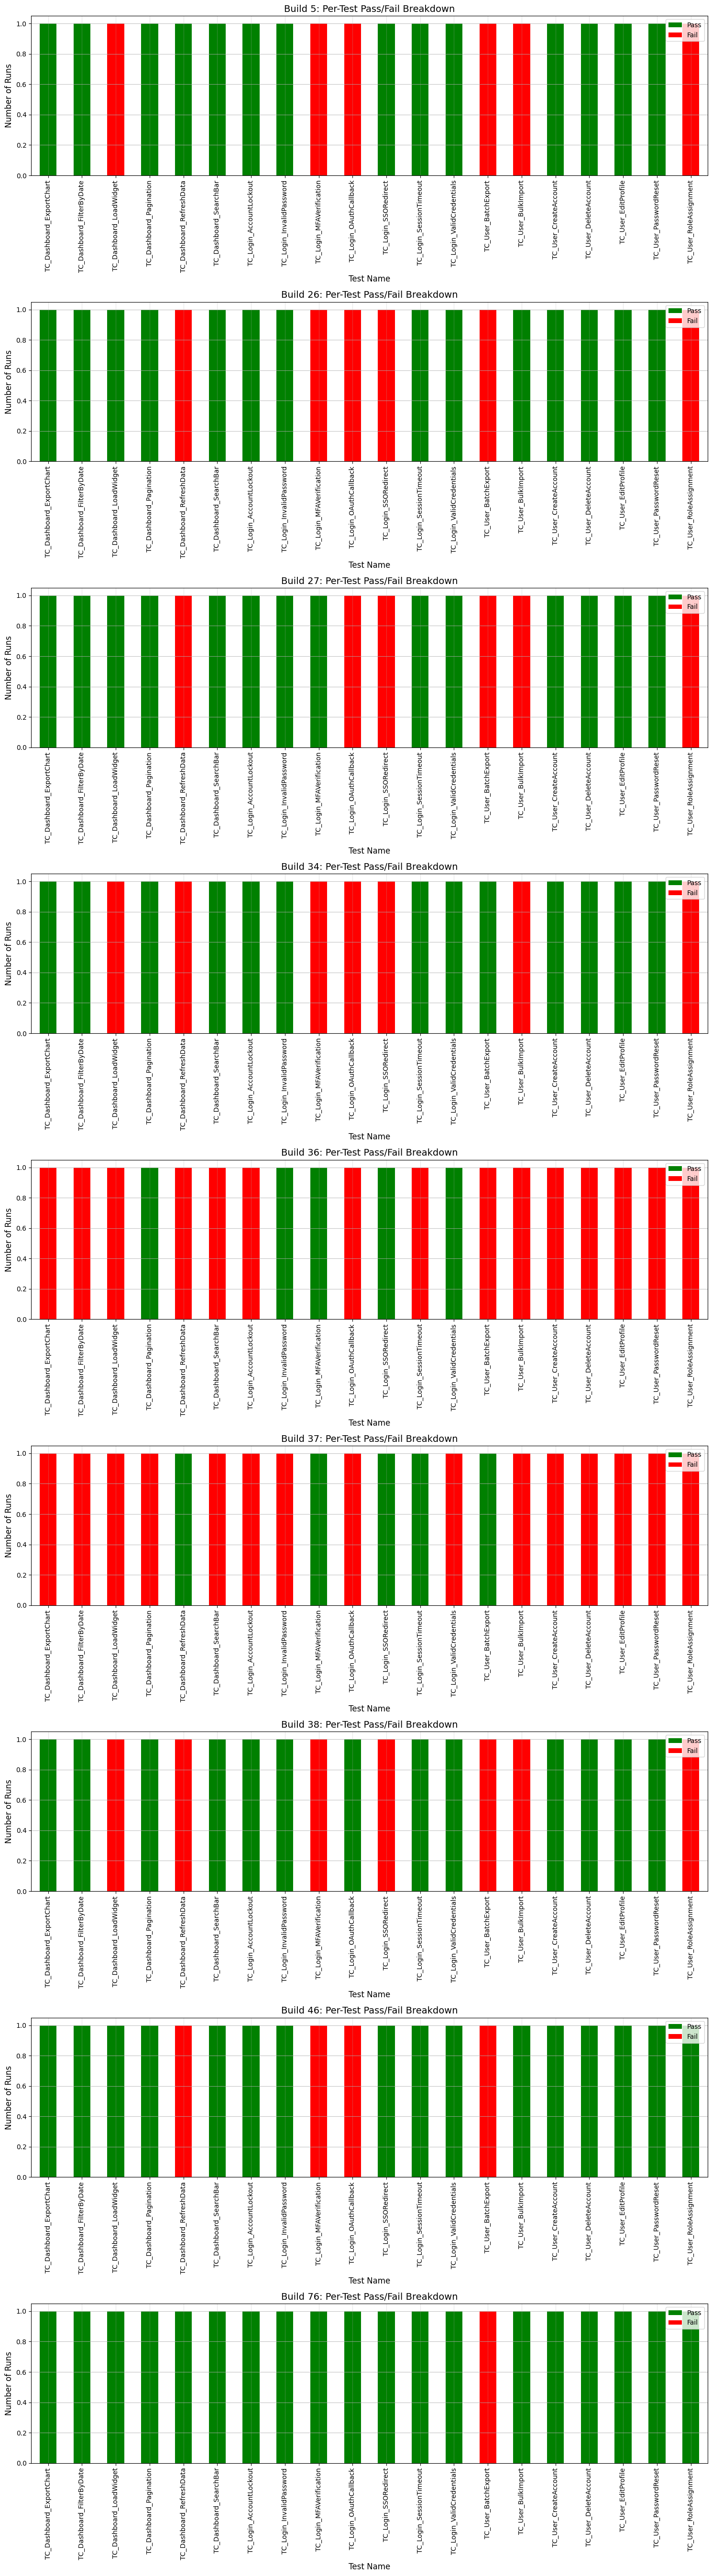

In [45]:
import matplotlib.pyplot as plt

anomalous_builds = df_runs[df_runs['anomaly_zscore'] | df_runs['anomaly_if']]['build_num'].unique()

if len(anomalous_builds) > 0:
    print(f"Analyzing anomalous builds: {sorted(anomalous_builds)}")
    if 'df_tests' not in globals() or df_tests.empty:
        import sqlite3
        import pandas as pd
        if 'DB_PATH' not in globals():
            DB_PATH = 'analytics.db'
        conn = sqlite3.connect(DB_PATH)
        df_tests = pd.read_sql_query(
            """
            SELECT
                tr.result_id,
                tr.run_id,
                tr.test_name,
                tr.status,
                tr.duration_s,
                r.build_no,
                r.timestamp,
                r.suite_name AS program
            FROM test_results tr
            JOIN runs r ON tr.run_id = r.run_id
            WHERE r.build_no IS NOT NULL
            ORDER BY tr.test_name, r.build_no
            """,
            conn
        )
        conn.close()
        df_tests['build_num'] = df_tests['run_id'].str.extract(r'(\d+)$').astype(int)

    df_anomalous_builds_tests = df_tests[df_tests['build_num'].isin(anomalous_builds)].copy()

    pivot_df = df_anomalous_builds_tests.groupby(['build_num', 'test_name', 'status']).size().unstack(fill_value=0)
    pivot_df['Total'] = pivot_df[['PASS', 'FAIL']].sum(axis=1)
    pivot_df = pivot_df.sort_values(by=['build_num', 'Total'], ascending=[True, False])

    num_anomalous_builds = len(anomalous_builds)
    fig, axes = plt.subplots(num_anomalous_builds, 1, figsize=(15, 6 * num_anomalous_builds), sharex=False)
    if num_anomalous_builds == 1:
        axes = [axes]

    for i, build_num in enumerate(sorted(anomalous_builds)):
        ax = axes[i]
        build_data = pivot_df.loc[build_num]

        if 'PASS' not in build_data.columns: build_data['PASS'] = 0
        if 'FAIL' not in build_data.columns: build_data['FAIL'] = 0

        build_data[['PASS', 'FAIL']].plot(kind='bar', stacked=True, ax=ax, color={'PASS': 'green', 'FAIL': 'red'})

        ax.set_title(f'Build {build_num}: Per-Test Pass/Fail Breakdown', fontsize=14)
        ax.set_xlabel('Test Name', fontsize=12)
        ax.set_ylabel('Number of Runs', fontsize=12)
        ax.tick_params(axis='x', rotation=90)
        ax.legend(['Pass', 'Fail'])
        ax.grid(axis='y', alpha=0.75)

    plt.tight_layout()
    plt.show()
else:
    print("No anomalous builds detected to visualize a per-test breakdown.")